*(cell 1)*

# 21 — Energy function: one concrete user, worked term by term

Standalone from `20_energy_function_5k.ipynb` on purpose. Notebook 20 reports **batch statistics** (real vs. shuffled energy, averaged over all 5,000 users) — this notebook is the single-user version, so the energy function's actual output can be inspected as one concrete number rather than an aggregate. Same demo user (3268) used throughout notebooks 17/18/19, so this is directly comparable to earlier demos.

No retraining anywhere here — loads `e₊`'s already-trained weights (`13b_encodingB_personality_training.ipynb`) and computes $E(v,h) = -v^\top W h - b_h^\top h$ (no visible bias term, matching the actual `train_rbm` implementation).

*(cell 2)*

## Part 0 — Setup

e+ : W (131290, 128)  bh (128,)  (frozen, trained in 13b)
Demo user: 3268
W_plus: shape=(131290, 128)  mean=-0.00425  std=0.01370  min=-0.1049  max=0.3670


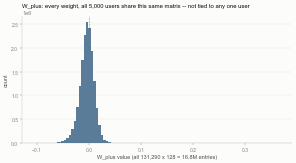

In [1]:
# cell 3
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 40  # keep the notebook file small -- 42 embedded charts otherwise bloat it

root = Path.cwd().resolve()
if root.name == "notebooks":
    root = root.parent

data_dir = root / "data"
proc = root / "data" / "processed"
out_dir = root / "outputs"
out_dir.mkdir(parents=True, exist_ok=True)
K = 10
DEMO_USER_ID = 3268


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -60.0, 60.0)))


W_plus = np.load(proc / "rbmB1_weights_5k.npy")
bh_plus = np.load(proc / "rbmB1_bias_hidden_5k.npy")
channelB1 = np.load(proc / "channelB1_softmax.npy", mmap_mode="r")
mask = np.load(proc / "mask.npy", mmap_mode="r")
cohort_user_ids = np.load(proc / "cohort_user_ids.npy").astype(int)
movie_vocab = np.load(proc / "movie_vocab.npy").astype(int)
n_movies = len(movie_vocab)
n_hidden = bh_plus.shape[0]
user_to_row = {int(uid): i for i, uid in enumerate(cohort_user_ids)}

print(f"e+ : W {W_plus.shape}  bh {bh_plus.shape}  (frozen, trained in 13b)")
print(f"Demo user: {DEMO_USER_ID}")

print(f"W_plus: shape={W_plus.shape}  mean={W_plus.mean():.5f}  std={W_plus.std():.5f}  min={W_plus.min():.4f}  max={W_plus.max():.4f}")

import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

fig, ax = plt.subplots(figsize=(7.5, 4.2), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.hist(W_plus.ravel(), bins=100, color="#5b7c99", zorder=3)
ax.axvline(0, color=INK_MUTED, linewidth=1, linestyle="--", zorder=2)
ax.set_xlabel("W_plus value (all 131,290 x 128 = 16.8M entries)", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel("count", color=INK_SECONDARY, fontsize=10)
ax.set_title("W_plus: every weight, all 5,000 users share this same matrix -- not tied to any one user", color=INK_PRIMARY, fontsize=10.5, loc="left")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(axis="y", color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / "W_plus_overall_distribution.png", dpi=150, facecolor=SURFACE)
plt.show()


*(cell 4)*

## Part 1 — Definitions: energy function and this user's rating distribution

### 2.1.1 Energy function

$$E(v,h) = -\sum_{i,k} a_{i,k}\, v_{i,k} \;-\; \sum_j b_j\, h_j \;-\; \sum_{i,k,j} v_{i,k}\, W_{(i,k),j}\, h_j$$

| Symbol | Meaning |
|---|---|
| $v_{i,k} \in \{0,1\}$ | Visible unit, one-hot -- movie $i$ ($i=1,\dots,13129$) at rating level $k$ ($k=1,\dots,10$, corresponding to 0.5-5.0). For a rated movie, exactly one $k$ is 1; unrated movies are all 0 (not in train, user_movie_in_train=0). |
| $h_j \in \{0,1\}$ | Hidden unit, binary, $j=1,\dots,128$. |
| $a_{i,k}$ | Visible bias -- baseline tendency for movie $i$ to receive rating level $k$, independent of any hidden unit. **Not present in the actual trained `e₊`** (13b never defines this parameter) -- included here for the full/formal definition. |
| $b_j$ | Hidden bias -- baseline tendency for hidden unit $j$ to activate. |
| $W_{(i,k),j}$ | Weight connecting visible unit $(i,k)$ to hidden unit $j$. |

### This user's rating distribution

Demo user 3268's real train-set ratings (`v` before any RBM computation touches it) -- shown before running anything through the model, since $v$ is the model's raw input, not a derived quantity.

In [2]:
# cell 5
from collections import Counter

RATING_LEVELS = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0])

cols_demo = np.where(np.asarray(mask[demo_row]) == 1)[0] if "demo_row" in dir() else np.where(np.asarray(mask[user_to_row[DEMO_USER_ID]]) == 1)[0]
demo_row = user_to_row[DEMO_USER_ID]
block_demo = np.asarray(channelB1[demo_row, cols_demo, :])
ks_demo = block_demo.argmax(axis=1)
ratings_demo = RATING_LEVELS[ks_demo]

print(f"User {DEMO_USER_ID}: {len(cols_demo)} rated movies in train set")
counts_demo = Counter(ratings_demo)
for r in RATING_LEVELS:
    c = counts_demo.get(r, 0)
    print(f"  {r:.1f} : {c:4d} ({c/len(ratings_demo)*100:5.1f}%)")
print(f"\nmean={ratings_demo.mean():.4f}  std={ratings_demo.std():.4f}")

User 3268: 696 rated movies in train set
  0.5 :    3 (  0.4%)
  1.0 :    1 (  0.1%)
  1.5 :    8 (  1.1%)
  2.0 :   12 (  1.7%)
  2.5 :   36 (  5.2%)
  3.0 :   99 ( 14.2%)
  3.5 :  185 ( 26.6%)
  4.0 :  256 ( 36.8%)
  4.5 :   78 ( 11.2%)
  5.0 :   18 (  2.6%)

mean=3.6466  std=0.6786


*(cell 6)*

#### Same distribution, as a chart

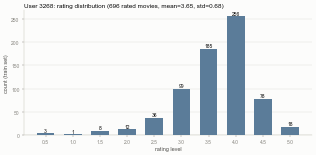

In [3]:
# cell 7
import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
BAR_COLOR = "#5b7c99"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

vals = [counts_demo.get(r, 0) for r in RATING_LEVELS]

fig, ax = plt.subplots(figsize=(8, 4), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.bar([f"{r:.1f}" for r in RATING_LEVELS], vals, color=BAR_COLOR, width=0.65, zorder=3)
for i, v in enumerate(vals):
    ax.text(i, v + max(vals) * 0.015, f"{v}", ha="center", fontsize=9, color=INK_PRIMARY)
ax.set_xlabel("rating level", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel("count (train set)", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"User {DEMO_USER_ID}: rating distribution ({len(cols_demo)} rated movies, "
             f"mean={ratings_demo.mean():.2f}, std={ratings_demo.std():.2f})",
             color=INK_PRIMARY, fontsize=11.5, loc="left")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(axis="y", color=GRID, linewidth=0.8, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_rating_distribution.png", dpi=150, facecolor=SURFACE)
plt.show()

*(cell 8)*

### The visible layer, concretely: one-hot, 0/1, with real movies

$v_{i,k}$ is not abstract -- for a handful of user 3268's actual rated movies, this is exactly what the one-hot row looks like: 10 slots per movie, exactly one 1, rest 0.

In [4]:
# cell 9
movies_title_map = pd.read_csv(data_dir / "movie.csv").set_index("movieId")["title"].to_dict()

target_levels = [0.5, 2.0, 3.0, 3.5, 4.0, 5.0]
picked_idx = []
for tl in target_levels:
    idxs = np.where(ratings_demo == tl)[0]
    if len(idxs):
        picked_idx.append(idxs[0])

mids_demo = movie_vocab[cols_demo]
sample_titles = [movies_title_map.get(int(mids_demo[i]), "?") for i in picked_idx]
sample_onehot = block_demo[picked_idx]  # (n_sample, K)

print("Sample of this user's real one-hot rows (movie x rating-level):")
for t, row_oh, r in zip(sample_titles, sample_onehot, [ratings_demo[i] for i in picked_idx]):
    print(f"  {t[:40]:40s} rating={r:.1f}  onehot={row_oh.astype(int).tolist()}")

Sample of this user's real one-hot rows (movie x rating-level):
  Napoleon Dynamite (2004)                 rating=0.5  onehot=[1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Zoolander (2001)                         rating=2.0  onehot=[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
  Casper (1995)                            rating=3.0  onehot=[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
  Jumanji (1995)                           rating=3.5  onehot=[0, 0, 0, 0, 0, 0, 1, 0, 0, 0]
  Toy Story (1995)                         rating=4.0  onehot=[0, 0, 0, 0, 0, 0, 0, 1, 0, 0]
  Léon: The Professional (a.k.a. The Profe rating=5.0  onehot=[0, 0, 0, 0, 0, 0, 0, 0, 0, 1]


*(cell 10)*

#### Same rows, as a visual grid

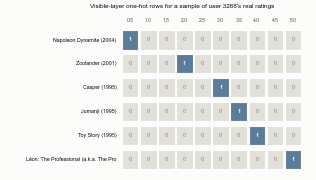

In [5]:
# cell 11
import matplotlib.pyplot as plt2

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
SURFACE = "#fcfcfb"
ZERO_COLOR, ONE_COLOR = "#e1e0d9", "#5b7c99"
plt2.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

n_sample = len(sample_titles)
fig, ax = plt2.subplots(figsize=(8, 0.55 * n_sample + 1.3), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

for row_i, (t, row_oh) in enumerate(zip(sample_titles, sample_onehot)):
    for col_j in range(K):
        val = int(row_oh[col_j])
        color = ONE_COLOR if val == 1 else ZERO_COLOR
        ax.add_patch(plt2.Rectangle((col_j, n_sample - 1 - row_i), 0.92, 0.8, facecolor=color, edgecolor=SURFACE, linewidth=2))
        txt_color = "white" if val == 1 else INK_MUTED
        ax.text(col_j + 0.46, n_sample - 1 - row_i + 0.4, str(val), ha="center", va="center", fontsize=10, color=txt_color, fontweight="bold" if val else "normal")
    ax.text(-0.3, n_sample - 1 - row_i + 0.4, t[:38], ha="right", va="center", fontsize=9.5, color=INK_PRIMARY)

for col_j, r in enumerate(RATING_LEVELS):
    ax.text(col_j + 0.46, n_sample + 0.15, f"{r:.1f}", ha="center", fontsize=9, color=INK_SECONDARY)

ax.set_xlim(-6.5, K + 0.5)
ax.set_ylim(-0.3, n_sample + 0.6)
ax.axis("off")
ax.set_title("Visible-layer one-hot rows for a sample of user 3268's real ratings", color=INK_PRIMARY, fontsize=11.5, loc="left", x=0.28)
plt2.tight_layout()
plt2.savefig(out_dir / "user3268_onehot_detail.png", dpi=150, facecolor=SURFACE)
plt2.show()

*(cell 12)*

### Introducing `e₊`

The definition above (§2.1.1) is generic -- it applies to any RBM channel. Instantiating it for `e₊` specifically:

- $W \to$ `W1` (shape `131290 x 128`, trained in `13b_encodingB_personality_training.ipynb`)
- $b \to$ `bh1` (shape `128`)
- $a \to$ **not present** -- confirmed earlier by reading `train_rbm` in 13b: no visible-bias parameter is ever initialized, updated, or used in the reconstruction step. The trained `e₊` is the no-bias special case of the formula above ($a_{i,k}=0$ for all $i,k$).
- $v \to$ user 3268's real rating vector (the distribution just plotted)

**CD-1's starting point -- the positive phase**: given the real data $v$, compute $P(h_j=1\mid v) = \text{sigmoid}\big(\sum_{i,k} v_{i,k}W_{(i,k),j} + b_j\big)$. This is the first quantity computed in the whole CD-1 cycle -- everything else (reconstruction, negative phase) is downstream of this.

In [6]:
# cell 13
# Positive phase: P(h=1 | v_data) = sigmoid(v_data @ W1 + bh1), using e+'s real trained weights
v_demo = np.asarray(channelB1[demo_row]).reshape(-1).astype(np.float64)
h_prob_positive = sigmoid(v_demo @ W_plus + bh_plus)

print(f"v (user {DEMO_USER_ID}'s real ratings): {int((v_demo != 0).sum())} nonzero entries")
print(f"h_prob (positive phase): shape={h_prob_positive.shape}")
print(f"  min={h_prob_positive.min():.4f}  max={h_prob_positive.max():.4f}  mean={h_prob_positive.mean():.4f}")
print(f"  first 10 values: {np.round(h_prob_positive[:10], 3)}")

v (user 3268's real ratings): 696 nonzero entries
h_prob (positive phase): shape=(128,)
  min=0.1544  max=1.0000  mean=0.8425
  first 10 values: [0.994 0.77  0.999 1.    1.    0.797 1.    0.37  0.154 0.998]


*(cell 14)*

### 2.1.2 Hammersley–Clifford → Gibbs distribution

The RBM's graph is **bipartite**: visible nodes $v_{i,k}$ and hidden nodes $h_j$, edges only between the two sides -- no $v$-$v$ edges, no $h$-$h$ edges. That specific structure gives the key conditional-independence (Markov) property: given $h$, all $v_{i,k}$ are independent of each other; given $v$, all $h_j$ are independent of each other. (This is exactly what makes Step 1a's computation a single vectorized `sigmoid` call over all 128 units at once, instead of 128 separate conditional computations -- each $h_j$ only depends on $v$, not on the other $h_{j'}$.)

**Hammersley–Clifford theorem**: for a Markov random field satisfying positivity (every configuration has nonzero probability, true here since sigmoid outputs are always strictly between 0 and 1), the joint distribution factorizes over the graph's *cliques*:

$$P(v,h) = \frac{1}{Z}\exp(-E(v,h))$$

For this bipartite graph, the only cliques are single nodes and single edges (no $v$-$v$ or $h$-$h$ edges means no larger clique exists). That is exactly why $E(v,h)$ from §2.1.1 has the form it does -- unary terms ($a_{i,k}v_{i,k}$, $b_jh_j$) for the size-1 cliques, plus pairwise terms ($v_{i,k}W_{(i,k),j}h_j$) for the size-2 cliques, and nothing higher-order. The energy function's shape is not an arbitrary choice -- it's what Hammersley–Clifford forces given this graph topology.

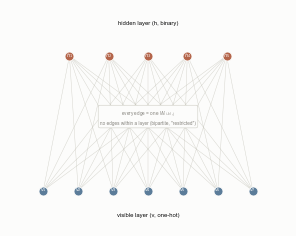

In [7]:
# cell 15
import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
SURFACE = "#fcfcfb"
V_COLOR, H_COLOR, EDGE_COLOR = "#5b7c99", "#b4654a", "#c3c2b7"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

n_v_show, n_h_show = 7, 5  # illustrative subset -- real graph is 131290 x 128, unreadable at full scale

fig, ax = plt.subplots(figsize=(7.5, 6), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

# transposed: hidden layer on TOP, visible layer on BOTTOM
v_x = np.linspace(0.1, 0.9, n_v_show)
h_x = np.linspace(0.2, 0.8, n_h_show)
v_y, h_y = 0.15, 0.8

for xv in v_x:
    for xh in h_x:
        ax.plot([xv, xh], [v_y, h_y], color=EDGE_COLOR, linewidth=0.8, zorder=1, alpha=0.7)

ax.scatter(h_x, [h_y] * n_h_show, s=260, color=H_COLOR, zorder=3, edgecolors=SURFACE, linewidths=1.5)
ax.scatter(v_x, [v_y] * n_v_show, s=260, color=V_COLOR, zorder=3, edgecolors=SURFACE, linewidths=1.5)

for j, xh in enumerate(h_x):
    ax.text(xh, h_y, f"$h_{{{j+1}}}$", ha="center", va="center", fontsize=9, color="white", zorder=4)
for i, xv in enumerate(v_x):
    ax.text(xv, v_y, f"$v_{{{i+1}}}$", ha="center", va="center", fontsize=9, color="white", zorder=4)

ax.text(0.5, 0.95, "hidden layer (h, binary)", ha="center", fontsize=10.5, color=INK_PRIMARY)
ax.text(0.5, 0.02, "visible layer (v, one-hot)", ha="center", fontsize=10.5, color=INK_PRIMARY)
ax.text(0.5, 0.5, "every edge = one $W_{(i,k),j}$\nno edges within a layer (bipartite, \"restricted\")",
        ha="center", va="center", fontsize=8.5, color=INK_MUTED,
        bbox=dict(boxstyle="round,pad=0.4", facecolor=SURFACE, edgecolor=EDGE_COLOR, linewidth=0.8))

ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.axis("off")
plt.tight_layout()
plt.savefig(out_dir / "rbm_bipartite_graph.png", dpi=150, facecolor=SURFACE)
plt.show()

*(cell 16)*

## CD-1, the four-step dance

*(cell 17)*

## Where does W_ikj actually come from? A real, 2-epoch training trajectory (cells 17-21)

**What "epoch" means**: one full pass through all 5,000 users (split into 10 batches of 500 each). The weight is updated once per epoch -- after all 10 batches finish, not after each batch. "Epoch 1" = the first full pass; "epoch 2" = the second.

**Why this section exists**: the weight values used everywhere above (e.g. Toy Story=4.0 -> unit 61 = +0.05105) are not derived from a formula in one step -- they are the end result of 50 such epochs of real CD-1 training (notebook 13b). Per-epoch snapshots were never saved during that original run, so instead of just asserting "it was trained," this section **re-runs the real training code** for 2 epochs (same random seed 42, same data) and records this one weight after each epoch.

### Step 1 -- the formula

$$\Delta W = \eta \cdot \big(\langle v h\rangle_{\text{data}} - \langle v h\rangle_{\text{recon}}\big)$$

Accumulated over the 10 batches within one epoch, then applied to $W$ once, at the end of that epoch. $\eta = 0.01$ (same learning rate as everywhere else in this notebook).

### Step 2 -- plug in the real data

Data source: `channelB1_softmax.npy` + `mask.npy` (same 5,000-user cohort), `N_HIDDEN=128, BATCH_SIZE=500, INIT_SEED=42` -- identical to 13b's actual setup. Starting from the exact same random initialization 13b used, run epoch 1, then epoch 2 -- each one accumulates `<vh>_data - <vh>_recon` over all 5,000 users, times `eta=0.01`. The actual computed `delta_W` for units 61/53/105, one row per epoch, is the first table below -- this **is** the formula's output with real numbers plugged in, not a guess.

### Step 3 -- result

`W` after applying each epoch's `delta_W` (`W <- W + delta_W`) -- the second table and the chart. (Only 2 of the real 50 epochs are run here, ~100s -- the ending values will NOT yet match the final trained W_plus, which takes all 50. This shows the real starting trajectory, not the full 50-epoch history.)


*(cell 18)*

##### Re-running real training, 2 epochs, tracking only 3 weight values

In [8]:
# cell 19
import time

# self-contained: locate Toy Story without depending on the later Setup cell
ts_pidx = picked_idx[sample_titles.index(next(t for t in sample_titles if t.startswith("Toy Story")))]
ts_movie_col = cols_demo[ts_pidx]
ts_level_idx = 7  # rating 4.0

N_EPOCHS_DEMO = 2
units_ts = [61, 53, 105]  # same 3 example units used throughout this section

def expand_mask_batch_demo(m_movies, k):
    return np.repeat(m_movies, k, axis=1)

print("Loading the same real data used by 13b's actual training...")
channelB1_full = np.load(proc / "channelB1_softmax.npy")
X1_demo = channelB1_full.reshape(channelB1_full.shape[0], -1)
del channelB1_full
mask_full = np.load(proc / "mask.npy")
M2_demo = mask_full.astype(X1_demo.dtype, copy=False)
n_samples_demo, n_visible_demo = X1_demo.shape

def get_ts_weights(W_snapshot):
    row = W_snapshot.reshape(n_movies, K, n_hidden)[ts_movie_col, ts_level_idx, :]
    return {u: float(row[u]) for u in units_ts}

rng_demo = np.random.default_rng(42)  # same INIT_SEED as 13b
W_demo = rng_demo.normal(0.0, 0.01, size=(n_visible_demo, n_hidden)).astype(np.float64)
b_h_demo = np.zeros(n_hidden, dtype=np.float64)

trajectory = {"init (before any training)": get_ts_weights(W_demo)}
delta_log = {}   # the formula's final output (LR * (data - recon)) each epoch
stat_log = {}    # the two RAW pieces the formula subtracts, before scaling by LR
ts_flat_idx = ts_movie_col * K + ts_level_idx  # this row's position in the flattened (movie*K) visible dim
print("init:", trajectory["init (before any training)"])

t0_all = time.perf_counter()
for epoch in range(N_EPOCHS_DEMO):
    t0 = time.perf_counter()
    epoch_delta = np.zeros_like(W_demo)
    data_stat_accum = {u: 0.0 for u in units_ts}    # accumulates <vh>_data for Toy Story=4.0, this epoch
    recon_stat_accum = {u: 0.0 for u in units_ts}   # accumulates <vh>_recon for Toy Story=4.0, this epoch
    order = rng_demo.permutation(n_samples_demo)
    for start in range(0, n_samples_demo, 500):
        idx = order[start:start + 500]
        v_data = np.asarray(X1_demo[idx])
        m_batch = expand_mask_batch_demo(M2_demo[idx], K).astype(X1_demo.dtype)
        bs = v_data.shape[0]

        h_prob = sigmoid(v_data @ W_demo + b_h_demo)
        h_data = (rng_demo.random(h_prob.shape) < h_prob).astype(np.float64)

        v_recon_prob = sigmoid(h_data @ W_demo.T) * m_batch
        v_recon = (rng_demo.random(v_recon_prob.shape) < v_recon_prob).astype(np.float64) * m_batch

        h_recon_prob = sigmoid(v_recon @ W_demo + b_h_demo)
        h_recon = (rng_demo.random(h_recon_prob.shape) < h_recon_prob).astype(np.float64)

        pos = v_data.T @ h_data
        neg = v_recon.T @ h_recon
        epoch_delta += 0.01 * (pos - neg) / bs  # LR=0.01, same as 13b
        b_h_demo += 0.01 * (h_prob.mean(axis=0) - h_recon_prob.mean(axis=0))

        # this batch's contribution to <vh>_data and <vh>_recon, for Toy Story=4.0, our 3 units only
        for u in units_ts:
            data_stat_accum[u] += pos[ts_flat_idx, u] / bs
            recon_stat_accum[u] += neg[ts_flat_idx, u] / bs

    # epoch_delta IS the formula's real output for this epoch -- capture it for our 3 units before it's applied
    delta_log[f"epoch {epoch + 1}"] = get_ts_weights(epoch_delta)
    stat_log[f"epoch {epoch + 1}"] = {
        u: {"data_stat": round(data_stat_accum[u], 5), "recon_stat": round(recon_stat_accum[u], 5),
            "data - recon": round(data_stat_accum[u] - recon_stat_accum[u], 5)}
        for u in units_ts
    }

    W_demo += epoch_delta
    dt = time.perf_counter() - t0
    ep = epoch + 1
    trajectory[f"after epoch {ep}"] = get_ts_weights(W_demo)
    print(f"epoch {ep} done in {dt:.1f}s")
    for u in units_ts:
        s = stat_log[f"epoch {ep}"][u]
        print(f"  unit {u}: data_stat={s['data_stat']:+.5f}  recon_stat={s['recon_stat']:+.5f}  "
              f"data-recon={s['data - recon']:+.5f}  x LR(0.01) = delta_W={delta_log[f'epoch {ep}'][u]:+.5f}")
    print(f"  W after applying it: {trajectory[f'after epoch {ep}']}")

print(f"\ntotal wall time: {time.perf_counter()-t0_all:.1f}s")
del X1_demo, M2_demo

print("\nStep 2, plugged in: the two raw pieces (<vh>_data, <vh>_recon) the formula subtracts, per epoch, per unit")
stat_rows = []
for ep_key, per_unit in stat_log.items():
    for u, vals in per_unit.items():
        stat_rows.append({"epoch": ep_key, "unit": u, **vals, "delta_W (x LR)": round(delta_log[ep_key][u], 5)})
stat_table = pd.DataFrame(stat_rows).set_index(["epoch", "unit"])
display(stat_table)

print("\nStep 3: W trajectory (init, then W += delta_W applied each epoch)")
traj_table = pd.DataFrame(trajectory).T
traj_table.index.name = "checkpoint"
display(traj_table)

print(f"\nfor comparison, actual W_plus after the real 50-epoch run: "
      f"{ {u: round(W_plus.reshape(n_movies,K,n_hidden)[ts_movie_col,ts_level_idx,u], 5) for u in units_ts} }")


Loading the same real data used by 13b's actual training...


init: {61: 0.02242920312402985, 53: -0.036484128252147835, 105: -0.007292869363736615}


epoch 1 done in 26.1s
  unit 61: data_stat=+1.41000  recon_stat=+1.99400  data-recon=-0.58400  x LR(0.01) = delta_W=-0.00584
  unit 53: data_stat=+1.34200  recon_stat=+2.03000  data-recon=-0.68800  x LR(0.01) = delta_W=-0.00688
  unit 105: data_stat=+1.31200  recon_stat=+2.19000  data-recon=-0.87800  x LR(0.01) = delta_W=-0.00878
  W after applying it: {61: 0.01658920312402985, 53: -0.04336412825214783, 105: -0.016072869363736614}


epoch 2 done in 23.9s
  unit 61: data_stat=+0.17600  recon_stat=+0.00000  data-recon=+0.17600  x LR(0.01) = delta_W=+0.00176
  unit 53: data_stat=+0.12000  recon_stat=+0.00000  data-recon=+0.12000  x LR(0.01) = delta_W=+0.00120
  unit 105: data_stat=+0.11400  recon_stat=+0.00000  data-recon=+0.11400  x LR(0.01) = delta_W=+0.00114
  W after applying it: {61: 0.01834920312402985, 53: -0.04216412825214783, 105: -0.014932869363736613}

total wall time: 50.0s

Step 2, plugged in: the two raw pieces (<vh>_data, <vh>_recon) the formula subtracts, per epoch, per unit


data_stat  recon_stat  data - recon  delta_W (x LR)
epoch   unit                                                     
epoch 1 61        1.410       1.994        -0.584        -0.00584
        53        1.342       2.030        -0.688        -0.00688
        105       1.312       2.190        -0.878        -0.00878
epoch 2 61        0.176       0.000         0.176         0.00176
        53        0.120       0.000         0.120         0.00120
        105       0.114       0.000         0.114         0.00114


Step 3: W trajectory (init, then W += delta_W applied each epoch)


,61,53,105
checkpoint,,,
init (before any training),0.022429,-0.036484,-0.007293
after epoch 1,0.016589,-0.043364,-0.016073
after epoch 2,0.018349,-0.042164,-0.014933



for comparison, actual W_plus after the real 50-epoch run: {61: np.float64(0.05105), 53: np.float64(-0.01384), 105: np.float64(-0.00037)}


*(cell 20)*

##### Trajectory, as a chart

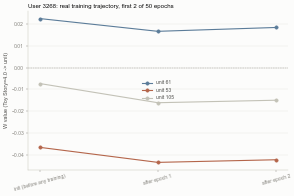

In [9]:
# cell 21
import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

palette = {61: "#5b7c99", 53: "#b4654a", 105: "#c3c2b7"}
x_labels = list(trajectory.keys())
x = np.arange(len(x_labels))

fig, ax = plt.subplots(figsize=(7.5, 5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
for u in units_ts:
    y = [trajectory[k][u] for k in x_labels]
    ax.plot(x, y, color=palette[u], linewidth=2, marker="o", markersize=6, zorder=3, label=f"unit {u}")
ax.axhline(0, color=INK_MUTED, linewidth=0.8, linestyle="--", zorder=1)
ax.set_xticks(x)
ax.set_xticklabels(x_labels, fontsize=9, rotation=15)
ax.set_ylabel("W value (Toy Story=4.0 -> unit)", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"User {DEMO_USER_ID}: real training trajectory, first 2 of 50 epochs", color=INK_PRIMARY, fontsize=11, loc="left")
ax.legend(loc="best", frameon=False, fontsize=9, labelcolor=INK_SECONDARY)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(axis="y", color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_toystory_weight_training.png", dpi=150, facecolor=SURFACE)
plt.show()


*(cell 22)*

#### Step 1 — Positive phase: $v^0 \to \sigma \to$ Bernoulli $\to h^0$

**Derivation (the sigmoid is not assumed -- it falls out of the energy function):**

Start from the Gibbs distribution, $P(v,h) = \frac{1}{Z}\exp(-E(v,h))$. Isolate the terms of $E(v,h)$ that involve one specific hidden unit $h_j$:

$$E(v,h) = C(v, h_{-j}) \;-\; h_j\underbrace{\Big(b_j + \sum_{i,k} v_{i,k}\,W_{(i,k),j}\Big)}_{=:\,I_j}$$

where $C(v,h_{-j})$ collects every term that does *not* depend on $h_j$ (the visible-bias terms and all other hidden units), and $I_j$ is the total input to unit $j$. Since $h_j\in\{0,1\}$, take the ratio of the two possible energies:

$$\frac{P(h_j{=}1\mid v)}{P(h_j{=}0\mid v)} = \frac{\exp(-E(v,h_j{=}1))}{\exp(-E(v,h_j{=}0))} = \frac{\exp(-(C-I_j))}{\exp(-C)} = \exp(I_j)$$

Combined with $P(h_j{=}1\mid v)+P(h_j{=}0\mid v)=1$:

$$P(h_j{=}1\mid v) = \frac{\exp(I_j)}{1+\exp(I_j)} = \frac{1}{1+\exp(-I_j)} = \sigma(I_j)$$

**Is-train check**: the sum $\sum_{i,k}$ only has nonzero contributions from movies $i$ this user actually rated in train (`user_movie_in_train[demo_row]==1`, backed by the `mask` array) -- for every unrated movie, $v_{i,k}=0$ for all $k=1,\dots,10$ by construction (nothing is one-hot there), so those positions contribute $0$ to $I_j$ automatically. This isn't a separate step here; it's structurally already enforced by how $v^0$ itself was built.

**Sampling**: $h_j^0 \sim \text{Bernoulli}\big(\sigma(I_j)\big)$.

*(cell 23)*

##### Train-set membership (user_movie_in_train), verified (not just claimed)

In [10]:
# cell 24
v0 = np.asarray(channelB1[demo_row]).reshape(-1).astype(np.float64)
n_rated_check = int(np.asarray(mask[demo_row]).sum())

# confirm masking is structural: unrated movies contribute exactly 0, not just "should"
rated_cols = np.where(np.asarray(mask[demo_row]) == 1)[0]
unrated_cols = np.where(np.asarray(mask[demo_row]) == 0)[0]
v0_reshaped = v0.reshape(n_movies, K)
print(f"v0: {int((v0 != 0).sum())} nonzero entries total")
print(f"  at RATED positions ({len(rated_cols)} movies): {int(v0_reshaped[rated_cols].sum())} ones (should = {len(rated_cols)}, one per movie)")
print(f"  at UNRATED positions ({len(unrated_cols)} movies): {int(v0_reshaped[unrated_cols].sum())} ones (should = 0)")


v0: 696 nonzero entries total
  at RATED positions (696 movies): 696 ones (should = 696, one per movie)
  at UNRATED positions (12433 movies): 0 ones (should = 0)


*(cell 25)*

##### Sigmoid: $I_j$ and $h_{\text{prob}}^0=\sigma(I_j)$

*How the probability is **computed**: a deterministic map from the energy function. The same $v^0$ always gives the same $h_{\text{prob}}^0$.*

I_j:       min=-1.7008  max=10.7256  mean=4.3634
h_prob_0 = sigma(I_j):  min=0.1544  max=1.0000  mean=0.8425
first 10 values: [0.994 0.77  0.999 1.    1.    0.797 1.    0.37  0.154 0.998]


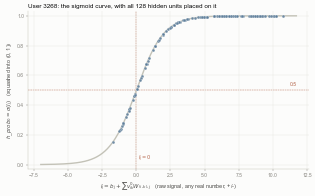

In [11]:
# cell 26
# sigmoid: I_j = b_j + sum v0_ik W_ikj,  h_prob_0 = sigma(I_j)
I_j = v0 @ W_plus + bh_plus
h_prob_0 = sigmoid(I_j)
print(f"I_j:       min={I_j.min():.4f}  max={I_j.max():.4f}  mean={I_j.mean():.4f}")
print(f"h_prob_0 = sigma(I_j):  min={h_prob_0.min():.4f}  max={h_prob_0.max():.4f}  mean={h_prob_0.mean():.4f}")
print(f"first 10 values: {np.round(h_prob_0[:10], 3)}")

import matplotlib.pyplot as plt
import numpy as np

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
CURVE_COLOR, DOT_COLOR, REF_COLOR = "#c3c2b7", "#5b7c99", "#b4654a"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

# the sigmoid S-curve itself: this is the map that turns any real number (positive or negative) into (0, 1)
x_curve = np.linspace(min(I_j.min(), -6) - 1, max(I_j.max(), 6) + 1, 400)
y_curve = sigmoid(x_curve)

fig, ax = plt.subplots(figsize=(8, 5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.plot(x_curve, y_curve, color=CURVE_COLOR, linewidth=2.5, zorder=2)
ax.scatter(I_j, h_prob_0, color=DOT_COLOR, s=28, zorder=3, alpha=0.85, edgecolors=SURFACE, linewidths=0.5)
ax.axhline(0.5, color=REF_COLOR, linewidth=0.8, linestyle="--", zorder=1)
ax.axvline(0, color=REF_COLOR, linewidth=0.8, linestyle="--", zorder=1)
ax.text(x_curve.max(), 0.53, "0.5", color=REF_COLOR, fontsize=9, ha="right")
ax.text(0.15, 0.03, "$I_j=0$", color=REF_COLOR, fontsize=9)

ax.set_xlabel(r"$I_j = b_j + \sum v^0_{ik} W_{(i,k),j}$   (raw signal, any real number, +/-)", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel(r"$h\_prob_0 = \sigma(I_j)$   (squashed into (0, 1))", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"User {DEMO_USER_ID}: the sigmoid curve, with all {n_hidden} hidden units placed on it", color=INK_PRIMARY, fontsize=11.5, loc="left")
ax.set_ylim(-0.03, 1.03)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_step1_sigmoid.png", dpi=150, facecolor=SURFACE)
plt.show()


*(cell 27)*

##### Bernoulli sample: $h^0$

*How the probability is **used**: a stochastic draw. The same $h_{\text{prob}}^0$ can give a different $h^0$ each time, but repeated draws converge back to $h_{\text{prob}}^0$.*

h0: 104 / 128 units sampled ON
which units: [0, 1, 2, 3, 4, 6, 9, 10, 11, 12, 13, 14, 15, 17, 18, 19, 20, 21, 22, 23, 25, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 40, 41, 42, 43, 44, 45, 46, 47, 48, 51, 52, 53, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 80, 81, 82, 84, 85, 86, 88, 89, 90, 91, 92, 93, 95, 96, 100, 101, 103, 104, 105, 106, 107, 108, 109, 111, 113, 114, 115, 116, 117, 119, 120, 121, 123, 124, 125, 126, 127]


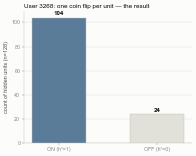

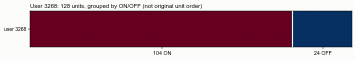

ON unit indices (original order in v/h): [0, 1, 2, 3, 4, 6, 9, 10, 11, 12, 13, 14, 15, 17, 18, 19, 20, 21, 22, 23, 25, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 40, 41, 42, 43, 44, 45, 46, 47, 48, 51, 52, 53, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 80, 81, 82, 84, 85, 86, 88, 89, 90, 91, 92, 93, 95, 96, 100, 101, 103, 104, 105, 106, 107, 108, 109, 111, 113, 114, 115, 116, 117, 119, 120, 121, 123, 124, 125, 126, 127]


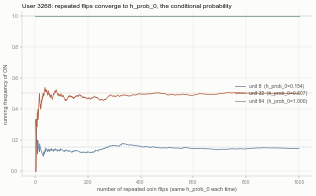

In [12]:
# cell 28
# Bernoulli sample: h0 ~ Bernoulli(h_prob_0)
rng_cd1 = np.random.default_rng(0)
h0 = (rng_cd1.random(h_prob_0.shape) < h_prob_0).astype(np.float64)
print(f"h0: {int(h0.sum())} / {n_hidden} units sampled ON")
print(f"which units: {np.where(h0 == 1)[0].tolist()}")

import matplotlib.pyplot as plt
import numpy as np

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
ON_COLOR, OFF_COLOR = "#5b7c99", "#e1e0d9"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

# ---- Chart A: one coin flip per unit -- the result distribution (ON vs OFF, this one draw) ----
n_on, n_off = int(h0.sum()), int(n_hidden - h0.sum())
fig, ax = plt.subplots(figsize=(5, 4), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
bars = ax.bar(["ON (h⁰=1)", "OFF (h⁰=0)"], [n_on, n_off], color=[ON_COLOR, OFF_COLOR], width=0.55, zorder=3, edgecolor=BASELINE, linewidth=0.8)
for b, v in zip(bars, [n_on, n_off]):
    ax.text(b.get_x() + b.get_width() / 2, v + max(n_on, n_off) * 0.02, f"{v}", ha="center", fontsize=11, color=INK_PRIMARY, fontweight="bold")
ax.set_ylabel(f"count of hidden units (n={n_hidden})", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"User {DEMO_USER_ID}: one coin flip per unit — the result", color=INK_PRIMARY, fontsize=11.5, loc="left")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9.5)
ax.grid(axis="y", color=GRID, linewidth=0.8, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_step1_bernoulli_result.png", dpi=150, facecolor=SURFACE)
plt.show()

# ---- Chart A2: WHICH units are ON vs OFF -- grouped (all ON together, all OFF together), not original order ----
on_units = np.where(h0 == 1)[0]
off_units = np.where(h0 == 0)[0]
grouped = np.concatenate([np.ones(len(on_units)), np.zeros(len(off_units))]).reshape(1, -1)

fig, ax = plt.subplots(figsize=(9, 1.6), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
im = ax.imshow(grouped, aspect="auto", cmap="RdBu_r", vmin=0, vmax=1)
ax.axvline(len(on_units) - 0.5, color=SURFACE, linewidth=2, zorder=3)
ax.set_yticks([0])
ax.set_yticklabels([f"user {DEMO_USER_ID}"], fontsize=9, color=INK_PRIMARY)
ax.set_xticks([len(on_units) / 2, len(on_units) + len(off_units) / 2])
ax.set_xticklabels([f"{len(on_units)} ON", f"{len(off_units)} OFF"], fontsize=9.5, color=INK_PRIMARY)
ax.set_title(f"User {DEMO_USER_ID}: 128 units, grouped by ON/OFF (not original unit order)", color=INK_PRIMARY, fontsize=10.5, loc="left")
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_step1_h0_map.png", dpi=150, facecolor=SURFACE, bbox_inches="tight")
plt.show()
print(f"ON unit indices (original order in v/h): {on_units.tolist()}")


# ---- Chart B: repeat the SAME coin (same h_prob_0) many times -- frequency converges to the conditional probability ----
rep_idx = [int(np.argmin(h_prob_0)), int(np.argmin(np.abs(h_prob_0 - 0.5))), int(np.argmax(h_prob_0))]
n_flips = 1000
rng_conv = np.random.default_rng(1)
palette = ["#5b7c99", "#b4654a", "#6b9080"]

fig, ax = plt.subplots(figsize=(8, 5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
for c, j in enumerate(rep_idx):
    draws = (rng_conv.random(n_flips) < h_prob_0[j]).astype(np.float64)
    running_freq = np.cumsum(draws) / np.arange(1, n_flips + 1)
    ax.plot(np.arange(1, n_flips + 1), running_freq, color=palette[c], linewidth=1.3, zorder=3,
            label=f"unit {j}  (h_prob_0={h_prob_0[j]:.3f})")
    ax.axhline(h_prob_0[j], color=palette[c], linewidth=0.8, linestyle="--", alpha=0.5, zorder=2)

ax.set_xlabel("number of repeated coin flips (same h_prob_0 each time)", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel("running frequency of ON", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"User {DEMO_USER_ID}: repeated flips converge to h_prob_0, the conditional probability", color=INK_PRIMARY, fontsize=11.5, loc="left")
ax.set_ylim(-0.03, 1.03)
ax.legend(loc="center right", frameon=False, fontsize=9, labelcolor=INK_SECONDARY)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_step1_bernoulli_convergence.png", dpi=150, facecolor=SURFACE)
plt.show()


*(cell 29)*

## Worked example: User 3268 x Toy Story, all 4 CD-1 steps in one place

Everything below reuses variables already computed earlier (v0, h_prob_0, h0, v1, h1_prob, delta_W, W_updated) -- nothing is recomputed from scratch. This section just slices out Toy Story specifically, at each of the 4 steps, next to its formula, so the whole story can be read top to bottom for one concrete (user, movie) pair.


*(cell 30)*

##### Setup: locate Toy Story in the data

Toy Story (1995): movie column=0, true rating=4.0
v0 one-hot row for Toy Story: [0, 0, 0, 0, 0, 0, 0, 1, 0, 0]


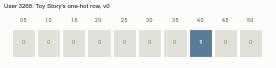

In [13]:
# cell 31
ts_pidx = picked_idx[sample_titles.index(next(t for t in sample_titles if t.startswith("Toy Story")))]
ts_movie_col = cols_demo[ts_pidx]
ts_level_idx = 7  # rating 4.0
print(f"Toy Story (1995): movie column={ts_movie_col}, true rating={RATING_LEVELS[ts_level_idx]}")
print(f"v0 one-hot row for Toy Story: {v0.reshape(n_movies, K)[ts_movie_col].astype(int).tolist()}")

import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
SURFACE = "#fcfcfb"
ZERO_COLOR, ONE_COLOR = "#e1e0d9", "#5b7c99"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

ts_row = v0.reshape(n_movies, K)[ts_movie_col].astype(int)

fig, ax = plt.subplots(figsize=(7, 1.8), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
for k in range(K):
    val = int(ts_row[k])
    color = ONE_COLOR if val == 1 else ZERO_COLOR
    ax.add_patch(plt.Rectangle((k, 0), 0.92, 0.8, facecolor=color, edgecolor=SURFACE, linewidth=2))
    txt_color = "white" if val == 1 else INK_MUTED
    ax.text(k + 0.46, 0.4, str(val), ha="center", va="center", fontsize=11, color=txt_color, fontweight="bold" if val else "normal")
for k, r in enumerate(RATING_LEVELS):
    ax.text(k + 0.46, 1.0, f"{r:.1f}", ha="center", fontsize=9.5, color=INK_SECONDARY)

ax.set_xlim(-0.3, K + 0.3)
ax.set_ylim(-0.2, 1.3)
ax.axis("off")
ax.set_title(f"User {DEMO_USER_ID}: Toy Story's one-hot row, v0", color=INK_PRIMARY, fontsize=11, loc="left")
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_toystory_onehot.png", dpi=150, facecolor=SURFACE)
plt.show()


*(cell 32)*

### Step 1 — Positive phase: v0 -> h0 (cells 32-38)

$$I_j = b_j + \sum_{(i,k)} v_{i,k}\, W_{(i,k),j} \qquad h\_prob_0 = \sigma(I_j) \qquad h^0 \sim \text{Bernoulli}(h\_prob_0)$$

$I_j$ sums over all 696 of this user's rated movies. Toy Story=4.0 is one of those 696 terms -- shown here isolated (its own contribution) against the full sum (all movies combined).


*(cell 33)*

##### 1.1 — Weighted sum: 696 movies -> I_j (Toy Story's term isolated)

,v_ik (Toy Story=4.0),W_ikj (weight),Toy Story's term (v*W),other 695 movies + bias,I_j (total)
unit,,,,,
61,1.0,0.05105,0.05105,9.23615,9.28720
53,1.0,-0.01384,-0.01384,7.77751,7.76366
105,1.0,-0.00037,-0.00037,2.98336,2.98299


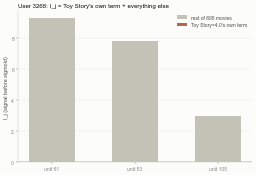

In [14]:
# cell 34
# I_j formula: I_j = bias + sum over all 696 rated (movie, level) pairs of v_ik * W_ikj
units_ts = [61, 53, 105]
v_ts = v0.reshape(n_movies, K)[ts_movie_col, ts_level_idx]  # = 1 (Toy Story is rated 4.0)

rows = []
for unit in units_ts:
    w_ts = W_plus.reshape(n_movies, K, n_hidden)[ts_movie_col, ts_level_idx, unit]
    ts_contribution = v_ts * w_ts
    other_695 = I_j[unit] - ts_contribution
    rows.append({
        "unit": unit,
        "v_ik (Toy Story=4.0)": v_ts,
        "W_ikj (weight)": round(w_ts, 5),
        "Toy Story's term (v*W)": round(ts_contribution, 5),
        "other 695 movies + bias": round(other_695, 5),
        "I_j (total)": round(I_j[unit], 5),
    })
toystory_table = pd.DataFrame(rows).set_index("unit")
display(toystory_table)

import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

ts_terms = [v0.reshape(n_movies, K)[ts_movie_col, ts_level_idx] * W_plus.reshape(n_movies, K, n_hidden)[ts_movie_col, ts_level_idx, u] for u in units_ts]
rest_terms = [I_j[u] - t for u, t in zip(units_ts, ts_terms)]

TS_COLOR, REST_COLOR = "#b4654a", "#c3c2b7"
fig, ax = plt.subplots(figsize=(6.5, 4.5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
x = np.arange(len(units_ts))
ax.bar(x, rest_terms, color=REST_COLOR, width=0.55, label="rest of 695 movies", zorder=3)
ax.bar(x, ts_terms, bottom=rest_terms, color=TS_COLOR, width=0.55, label="Toy Story=4.0's own term", zorder=3)
ax.axhline(0, color=INK_MUTED, linewidth=0.8, zorder=2)
ax.set_xticks(x)
ax.set_xticklabels([f"unit {u}" for u in units_ts], fontsize=9.5)
ax.set_ylabel("I_j (signal before sigmoid)", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"User {DEMO_USER_ID}: I_j = Toy Story's own term + everything else", color=INK_PRIMARY, fontsize=11, loc="left")
ax.legend(loc="upper right", frameon=False, fontsize=9, labelcolor=INK_SECONDARY)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(axis="y", color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_toystory_step1a.png", dpi=150, facecolor=SURFACE)
plt.show()


*(cell 35)*

##### 1.2 — Probability: I_j -> sigmoid -> h_prob_0

h_prob_0 = sigma(I_j), for the same 3 units:
  unit 61: I_j=+9.2872  ->  h_prob_0=0.9999
  unit 53: I_j=+7.7637  ->  h_prob_0=0.9996
  unit 105: I_j=+2.9830  ->  h_prob_0=0.9518


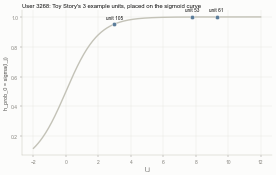

In [15]:
# cell 36
print("h_prob_0 = sigma(I_j), for the same 3 units:")
for unit in units_ts:
    print(f"  unit {unit}: I_j={I_j[unit]:+.4f}  ->  h_prob_0={h_prob_0[unit]:.4f}")

import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
CURVE_COLOR, DOT_COLOR = "#c3c2b7", "#5b7c99"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

x_curve = np.linspace(-2, 12, 300)
y_curve = sigmoid(x_curve)
fig, ax = plt.subplots(figsize=(7, 4.5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.plot(x_curve, y_curve, color=CURVE_COLOR, linewidth=2.5, zorder=2)
for unit in units_ts:
    ax.scatter([I_j[unit]], [h_prob_0[unit]], color=DOT_COLOR, s=60, zorder=3, edgecolors=SURFACE, linewidths=0.8)
    ax.annotate(f"unit {unit}", (I_j[unit], h_prob_0[unit]), textcoords="offset points", xytext=(0, 10), fontsize=8.5, ha="center", color=INK_PRIMARY)
ax.set_xlabel("I_j", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel("h_prob_0 = sigma(I_j)", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"User {DEMO_USER_ID}: Toy Story's 3 example units, placed on the sigmoid curve", color=INK_PRIMARY, fontsize=10.5, loc="left")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_toystory_step1b.png", dpi=150, facecolor=SURFACE)
plt.show()


*(cell 37)*

##### 1.3 — Coin flip: h_prob_0 -> Bernoulli -> h0

h0 ~ Bernoulli(h_prob_0), for the same 3 units:
  unit 61: h_prob_0=0.9999  ->  h0=1
  unit 53: h_prob_0=0.9996  ->  h0=1
  unit 105: h_prob_0=0.9518  ->  h0=1


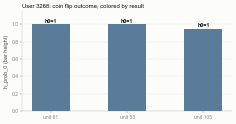

In [16]:
# cell 38
print("h0 ~ Bernoulli(h_prob_0), for the same 3 units:")
for unit in units_ts:
    print(f"  unit {unit}: h_prob_0={h_prob_0[unit]:.4f}  ->  h0={int(h0[unit])}")

import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
SURFACE = "#fcfcfb"
ON_COLOR, OFF_COLOR = "#5b7c99", "#e1e0d9"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

fig, ax = plt.subplots(figsize=(6, 3.2), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
for i, unit in enumerate(units_ts):
    color = ON_COLOR if h0[unit] == 1 else OFF_COLOR
    ax.bar([i], [h_prob_0[unit]], color=color, width=0.5, zorder=3)
    ax.text(i, h_prob_0[unit] + 0.02, f"h0={int(h0[unit])}", ha="center", fontsize=9.5, color=INK_PRIMARY, fontweight="bold")
ax.set_xticks(range(len(units_ts)))
ax.set_xticklabels([f"unit {u}" for u in units_ts], fontsize=9.5)
ax.set_ylabel("h_prob_0 (bar height)", color=INK_SECONDARY, fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_title(f"User {DEMO_USER_ID}: coin flip outcome, colored by result", color=INK_PRIMARY, fontsize=10.5, loc="left")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(axis="y", color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_toystory_step1c.png", dpi=150, facecolor=SURFACE)
plt.show()


*(cell 39)*

### Movie-side vs. user-side, made visible (using e+'s W1/h⁰ as the concrete example)

*Aside, not part of CD-1's four steps -- background on why personalization comes from v0 rather than W, plus the ablation-verified weight-sign examples. Skip to Step 2 (cell 45) to continue the CD-1 sequence.*

Two charts: first the two structures **separately** (W's rows vs. h's one row), then **combined** (the actual matrix multiplication that turns one into the other for this one user).


*(cell 40)*

##### Separate: W (movie-side, many rows) vs. h⁰ (user-side, one row)

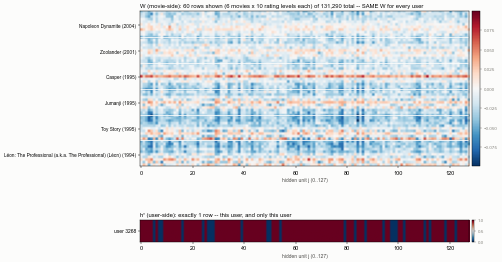

In [17]:
# cell 41
import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
SURFACE = "#fcfcfb"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

# W restricted to the 6 sample movies' 10 rating-level rows each -- real slice of the real W, movie-indexed
W_slice = W_plus.reshape(n_movies, K, n_hidden)[cols_demo[picked_idx]]  # (6 movies, 10 levels, 128 hidden)
W_slice_flat = W_slice.reshape(-1, n_hidden)  # (60, 128)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7.5), facecolor=SURFACE, gridspec_kw={"height_ratios": [7, 1], "hspace": 0.6})

vmax = float(np.abs(W_slice_flat).max())
im1 = ax1.imshow(W_slice_flat, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
ax1.set_yticks([5 + 10 * i for i in range(len(sample_titles))])
ax1.set_yticklabels(sample_titles, fontsize=8.5, color=INK_PRIMARY)
for i in range(1, len(sample_titles)):
    ax1.axhline(i * 10 - 0.5, color=SURFACE, linewidth=1.5)
ax1.set_xlabel("hidden unit j (0..127)", fontsize=9, color=INK_SECONDARY)
ax1.set_title(f"W (movie-side): {W_slice_flat.shape[0]} rows shown (6 movies x 10 rating levels each) of {n_movies*K:,} total -- SAME W for every user", fontsize=10.5, color=INK_PRIMARY, loc="left")
cb1 = plt.colorbar(im1, ax=ax1, pad=0.01, fraction=0.025)
cb1.ax.tick_params(labelsize=8, colors=INK_MUTED)

im2 = ax2.imshow(h0.reshape(1, -1), aspect="auto", cmap="RdBu_r", vmin=0, vmax=1)
ax2.set_yticks([0])
ax2.set_yticklabels([f"user {DEMO_USER_ID}"], fontsize=9, color=INK_PRIMARY)
ax2.set_xlabel("hidden unit j (0..127)", fontsize=9, color=INK_SECONDARY)
ax2.set_title("h⁰ (user-side): exactly 1 row -- this user, and only this user", fontsize=10.5, color=INK_PRIMARY, loc="left")
cb2 = plt.colorbar(im2, ax=ax2, pad=0.01, fraction=0.025)
cb2.ax.tick_params(labelsize=8, colors=INK_MUTED)

plt.savefig(out_dir / f"user{DEMO_USER_ID}_movie_vs_user_side.png", dpi=150, facecolor=SURFACE, bbox_inches="tight")
plt.show()


*(cell 42)*

##### The three verified examples (>0, <0, ≈0), circled on the real W heatmap from the chart above

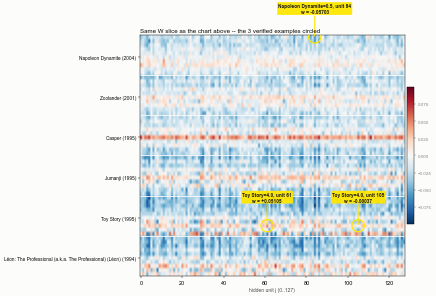

In [18]:
# cell 43
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
SURFACE = "#fcfcfb"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

# same slice as the chart in cell 26 -- 6 sample movies x 10 rating levels, all 128 hidden units
W_slice = W_plus.reshape(n_movies, K, n_hidden)[cols_demo[picked_idx]]
W_slice_flat = W_slice.reshape(-1, n_hidden)

# the 3 verified examples, located within this exact slice
# sample_titles order: Napoleon Dynamite(row 0), Zoolander(10), Casper(20), Jumanji(30), Toy Story(40), Leon(50)
examples = [
    {"label": "Toy Story=4.0, unit 61",        "row": 4 * 10 + 7, "col": 61,  "color": "#ffe600"},
    {"label": "Napoleon Dynamite=0.5, unit 84", "row": 0 * 10 + 0, "col": 84,  "color": "#ffe600"},
    {"label": "Toy Story=4.0, unit 105",        "row": 4 * 10 + 7, "col": 105, "color": "#ffe600"},
]
for ex in examples:
    ex["weight"] = W_slice_flat[ex["row"], ex["col"]]
    ex["label"] = f"{ex['label']}\nw = {ex['weight']:+.5f}"

fig, ax = plt.subplots(figsize=(11, 7.5), facecolor=SURFACE)
vmax = float(np.abs(W_slice_flat).max())
im = ax.imshow(W_slice_flat, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
ax.set_yticks([5 + 10 * i for i in range(len(sample_titles))])
ax.set_yticklabels(sample_titles, fontsize=8.5, color=INK_PRIMARY)
for i in range(1, len(sample_titles)):
    ax.axhline(i * 10 - 0.5, color=SURFACE, linewidth=1.5)
ax.set_xlabel("hidden unit j (0..127)", fontsize=9, color=INK_SECONDARY)
ax.set_title("Same W slice as the chart above -- the 3 verified examples circled", fontsize=11, color=INK_PRIMARY, loc="left")
cb = plt.colorbar(im, ax=ax, pad=0.01, fraction=0.025)
cb.ax.tick_params(labelsize=8, colors=INK_MUTED)

for ex in examples:
    ax.add_patch(Ellipse((ex["col"], ex["row"]), width=6, height=3, fill=False, edgecolor=ex["color"], linewidth=2.2, zorder=5))
    ax.annotate(ex["label"], xy=(ex["col"], ex["row"]), xytext=(ex["col"], ex["row"] - 6),
                fontsize=8.5, color="#1a1a1a", ha="center", fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.2", facecolor=ex["color"], edgecolor="none", alpha=0.95),
                arrowprops=dict(arrowstyle="-", color=ex["color"], linewidth=2))

plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_weight_examples_circled.png", dpi=150, facecolor=SURFACE, bbox_inches="tight")
plt.show()


*(cell 44)*

##### Combined: $v^0 \,@\, W + b = I_j \to \sigma \to h^0$ -- movie-side in, user-side out

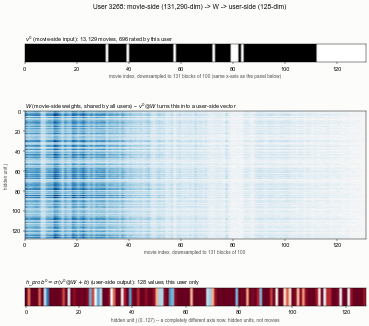

In [19]:
# cell 45
import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
SURFACE = "#fcfcfb"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

# downsample EVERYTHING to the same movie-block scale, so the three panels stay honestly aligned on the x-axis
block = 100
n_blocks = n_movies // block

v0_by_movie = (v0.reshape(n_movies, K).sum(axis=1) > 0).astype(float)          # (n_movies,) rated=1/unrated=0
v0_downsampled = v0_by_movie[:n_blocks * block].reshape(n_blocks, block).max(axis=1)   # (n_blocks,) -- any rated in this block?

W_mean_over_k = W_plus.reshape(n_movies, K, n_hidden).mean(axis=1)             # (n_movies, 128)
W_downsampled = W_mean_over_k[:n_blocks * block].reshape(n_blocks, block, n_hidden).mean(axis=1)  # (n_blocks, 128)

fig, axes = plt.subplots(3, 1, figsize=(11, 8.5), facecolor=SURFACE, gridspec_kw={"height_ratios": [1, 7, 1], "hspace": 0.9})
ax0, ax1, ax2 = axes

ax0.imshow(v0_downsampled.reshape(1, -1), aspect="auto", cmap="Greys", vmin=0, vmax=1, extent=[0, n_blocks, 0, 1])
ax0.set_yticks([])
ax0.set_xlabel(f"movie index, downsampled to {n_blocks} blocks of {block} (same x-axis as the panel below)", fontsize=8.5, color=INK_SECONDARY)
ax0.set_title(f"$v^0$ (movie-side input): {n_movies:,} movies, {int(v0_by_movie.sum())} rated by this user", fontsize=10, color=INK_PRIMARY, loc="left")

vmax = float(np.abs(W_downsampled).max())
im1 = ax1.imshow(W_downsampled.T, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax, extent=[0, n_blocks, n_hidden, 0])
ax1.set_ylabel("hidden unit j", fontsize=8.5, color=INK_SECONDARY)
ax1.set_xlabel(f"movie index, downsampled to {n_blocks} blocks of {block}", fontsize=8.5, color=INK_SECONDARY)
ax1.set_title(r"$W$ (movie-side weights, shared by all users) -- $v^0 @ W$ turns this into a user-side vector", fontsize=10, color=INK_PRIMARY, loc="left")

ax2.imshow(h_prob_0.reshape(1, -1), aspect="auto", cmap="RdBu_r", vmin=0, vmax=1)
ax2.set_yticks([])
ax2.set_xlabel("hidden unit j (0..127) -- a completely different axis now: hidden units, not movies", fontsize=8.5, color=INK_SECONDARY)
ax2.set_title(r"$h\_prob^0=\sigma(v^0 @ W + b)$ (user-side output): 128 values, this user only", fontsize=10, color=INK_PRIMARY, loc="left")

fig.suptitle(f"User {DEMO_USER_ID}: movie-side ({n_movies*K:,}-dim) -> W -> user-side (128-dim)", fontsize=12, color=INK_PRIMARY, y=1.0)
plt.savefig(out_dir / f"user{DEMO_USER_ID}_movie_to_user_combined.png", dpi=150, facecolor=SURFACE, bbox_inches="tight")
plt.show()


*(cell 46)*

## Step 2 — Reconstruction: h⁰ → v¹ → h¹

### h⁰ → v¹, softmax over each movie's K rating bins (Salakhutdinov, Mnih & Hinton, 2007)

Each movie's K one-hot positions aren't K independent binary units -- a movie has exactly one rating, so they're a single categorical variable. The correct conditional distribution ties all K bins together with a softmax, not K separate sigmoids:

$$J_{i,k} := \sum_j W_{(i,k),j}\, h_j^0 \qquad \text{(no visible bias } a_{i,k}\text{, same omission as e+'s actual trained form)}$$

$$v^1_{i,k} := P(v_{i,k}=1 \mid h^0) = \frac{\exp(J_{i,k})}{\sum_{k'=1}^{K} \exp(J_{i,k'})}$$

This guarantees $\sum_k v^1_{i,k}=1$ for every movie $i$ -- a genuine probability distribution over the 10 rating levels, unlike treating each bin as an independent sigmoid. Is-train: same as Step 1 -- only the movies this user actually rated in train are kept, the rest are forced to 0.

### v¹ → h¹, sigmoid (probabilities only -- no Bernoulli sample here)

Same rule as Step 1's positive phase, but now driven by the reconstruction $v^1$ instead of the real $v^0$:

$$h^1_j := P(h_j=1 \mid v^1) = \sigma\Big(b_j + \sum_{i,k} v^1_{i,k}\, W_{(i,k),j}\Big)$$

$h^1$ stops at the probability here -- it isn't sampled to a binary value until Step 3.


*(cell 47)*

##### 2.1 — $h^0 \to v^1$: softmax reconstruction, per movie

v1 row sums at RATED movies:   min=1.0000  max=1.0000  (should = 1.0)
v1 row sums at UNRATED movies: min=0.0000  max=0.0000  (should = 0.0)


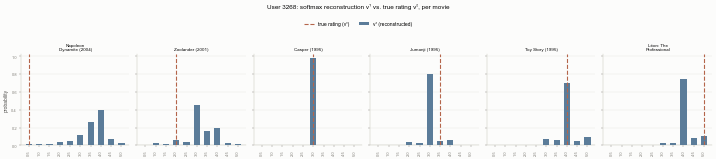

In [20]:
# cell 48
# Step 2, part A: h0 -> softmax over each movie's K rating bins -> v1 (reconstruction)
J_v = (h0 @ W_plus.T).reshape(n_movies, K)          # no visible bias, same omission as e+'s trained form
J_v_shift = J_v - J_v.max(axis=1, keepdims=True)     # numerical stability, does not change the softmax result
exp_J = np.exp(J_v_shift)
v1_full = exp_J / exp_J.sum(axis=1, keepdims=True)   # softmax per movie row -- every row sums to 1

mask_col = np.asarray(mask[demo_row]).astype(np.float64)   # (n_movies,)
v1 = v1_full * mask_col[:, None]                     # masking: same treatment as Step 1, only rated movies kept

row_sums = v1.sum(axis=1)
print(f"v1 row sums at RATED movies:   min={row_sums[rated_cols].min():.4f}  max={row_sums[rated_cols].max():.4f}  (should = 1.0)")
print(f"v1 row sums at UNRATED movies: min={row_sums[unrated_cols].min():.4f}  max={row_sums[unrated_cols].max():.4f}  (should = 0.0)")

import textwrap

import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
TRUE_COLOR, RECON_COLOR = "#b4654a", "#5b7c99"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

def wrap_title(t, width=16, max_lines=2):
    t = t.split(" (a.k.a")[0]  # drop redundant alt-title suffixes, e.g. "Leon ... (a.k.a. The Professional)"
    lines = textwrap.wrap(t, width)
    if len(lines) > max_lines:
        lines = lines[:max_lines]
        lines[-1] = lines[-1].rstrip() + "..."
    return "\n".join(lines)

n_sample = len(picked_idx)
fig, axes = plt.subplots(1, n_sample, figsize=(3.0 * n_sample, 3.4), facecolor=SURFACE, sharey=True)
if n_sample == 1:
    axes = [axes]

x = np.arange(K)
for ax, pidx, title in zip(axes, picked_idx, sample_titles):
    movie_col = cols_demo[pidx]
    true_row = block_demo[pidx]
    recon_row = v1[movie_col]
    ax.set_facecolor(SURFACE)
    ax.bar(x, recon_row, color=RECON_COLOR, width=0.6, zorder=3, label="v¹ (reconstructed)")
    true_k = int(true_row.argmax())
    ax.axvline(true_k, color=TRUE_COLOR, linewidth=2, linestyle="--", zorder=4, label="true rating (v⁰)")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{r:.1f}" for r in RATING_LEVELS], rotation=90, fontsize=7)
    ax.set_title(wrap_title(title), fontsize=8, color=INK_PRIMARY)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(BASELINE)
    ax.tick_params(colors=INK_MUTED, labelsize=7.5)
    ax.grid(axis="y", color=GRID, linewidth=0.6, zorder=0)

axes[0].set_ylabel("probability", color=INK_SECONDARY, fontsize=9)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, fontsize=9, bbox_to_anchor=(0.5, 1.06))
fig.suptitle(f"User {DEMO_USER_ID}: softmax reconstruction v¹ vs. true rating v⁰, per movie", fontsize=11.5, color=INK_PRIMARY, y=1.16)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_step2_softmax.png", dpi=150, facecolor=SURFACE, bbox_inches="tight")
plt.show()


*(cell 49)*

##### 2.2 — $v^1$ as a table, same format as $v^0$'s one-hot table -- but probabilities, not 0/1

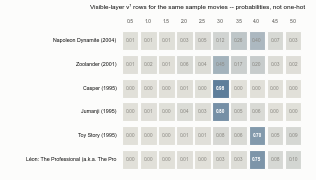

In [21]:
# cell 50
import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
SURFACE = "#fcfcfb"
ZERO_RGB, ONE_RGB = (0xe1, 0xe0, 0xd9), (0x5b, 0x7c, 0x99)  # same two colors as v0's grid, blended by value now
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]


def blend(val):
    r = ZERO_RGB[0] + (ONE_RGB[0] - ZERO_RGB[0]) * val
    g = ZERO_RGB[1] + (ONE_RGB[1] - ZERO_RGB[1]) * val
    b = ZERO_RGB[2] + (ONE_RGB[2] - ZERO_RGB[2]) * val
    return (r / 255, g / 255, b / 255)


n_sample = len(sample_titles)
fig, ax = plt.subplots(figsize=(8, 0.55 * n_sample + 1.3), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

for row_i, (t, pidx) in enumerate(zip(sample_titles, picked_idx)):
    row_v1 = v1[cols_demo[pidx]]  # this movie's reconstructed probability distribution, K values summing to 1
    for col_j in range(K):
        val = float(row_v1[col_j])
        color = blend(val)
        ax.add_patch(plt.Rectangle((col_j, n_sample - 1 - row_i), 0.92, 0.8, facecolor=color, edgecolor=SURFACE, linewidth=2))
        txt_color = "white" if val > 0.5 else INK_MUTED
        ax.text(col_j + 0.46, n_sample - 1 - row_i + 0.4, f"{val:.2f}", ha="center", va="center", fontsize=8.5, color=txt_color, fontweight="bold" if val > 0.5 else "normal")
    ax.text(-0.3, n_sample - 1 - row_i + 0.4, t[:38], ha="right", va="center", fontsize=9.5, color=INK_PRIMARY)

for col_j, r in enumerate(RATING_LEVELS):
    ax.text(col_j + 0.46, n_sample + 0.15, f"{r:.1f}", ha="center", fontsize=9, color=INK_SECONDARY)

ax.set_xlim(-6.5, K + 0.5)
ax.set_ylim(-0.3, n_sample + 0.6)
ax.axis("off")
ax.set_title("Visible-layer v¹ rows for the same sample movies -- probabilities, not one-hot", color=INK_PRIMARY, fontsize=11.5, loc="left", x=0.28)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_v1_detail.png", dpi=150, facecolor=SURFACE)
plt.show()


*(cell 51)*

##### 2.3 — $v^1 \to h^1$: sigmoid, probabilities only

I_j (from v1):          min=2.6623  max=11.7675  mean=6.5826
h1_prob = sigma(I_j):   min=0.9348  max=1.0000  mean=0.9910
first 10 values: [0.999 0.995 1.    1.    1.    0.958 1.    0.953 0.974 1.   ]
(compare to h_prob_0 from Step 1, mean=0.8425 -- real data vs. reconstruction-driven)


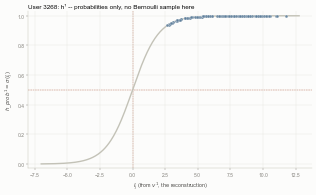


h1_prob - h_prob_0 per unit: min=-0.0009  max=0.8195  mean=0.1484
units where h1 < h0: 8 / 128   (diff is a continuum, not two separate groups -- colored by magnitude below, not binned)


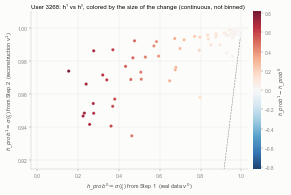

In [22]:
# cell 52
# Step 2, part B: v1 -> sigmoid -> h1 (probabilities only, no Bernoulli sample here)
I_j_1 = v1.reshape(-1) @ W_plus + bh_plus
h1_prob = sigmoid(I_j_1)
print(f"I_j (from v1):          min={I_j_1.min():.4f}  max={I_j_1.max():.4f}  mean={I_j_1.mean():.4f}")
print(f"h1_prob = sigma(I_j):   min={h1_prob.min():.4f}  max={h1_prob.max():.4f}  mean={h1_prob.mean():.4f}")
print(f"first 10 values: {np.round(h1_prob[:10], 3)}")
print(f"(compare to h_prob_0 from Step 1, mean={h_prob_0.mean():.4f} -- real data vs. reconstruction-driven)")

import matplotlib.pyplot as plt
import numpy as np

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
CURVE_COLOR, DOT_COLOR, REF_COLOR = "#c3c2b7", "#5b7c99", "#b4654a"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

x_curve = np.linspace(min(I_j_1.min(), -6) - 1, max(I_j_1.max(), 6) + 1, 400)
y_curve = sigmoid(x_curve)

fig, ax = plt.subplots(figsize=(8, 5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.plot(x_curve, y_curve, color=CURVE_COLOR, linewidth=2.5, zorder=2)
ax.scatter(I_j_1, h1_prob, color=DOT_COLOR, s=28, zorder=3, alpha=0.85, edgecolors=SURFACE, linewidths=0.5)
ax.axhline(0.5, color=REF_COLOR, linewidth=0.8, linestyle="--", zorder=1)
ax.axvline(0, color=REF_COLOR, linewidth=0.8, linestyle="--", zorder=1)
ax.set_xlabel(r"$I_j$ (from $v^1$, the reconstruction)", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel(r"$h\_prob^1=\sigma(I_j)$", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"User {DEMO_USER_ID}: h¹ -- probabilities only, no Bernoulli sample here", color=INK_PRIMARY, fontsize=11.5, loc="left")
ax.set_ylim(-0.03, 1.03)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_step2_sigmoid.png", dpi=150, facecolor=SURFACE)
plt.show()


# ---- extra: h1_prob vs h_prob_0 -- for each hidden unit, is the change higher or lower, and by how much? ----
diff = h1_prob - h_prob_0
print(f"\nh1_prob - h_prob_0 per unit: min={diff.min():.4f}  max={diff.max():.4f}  mean={diff.mean():.4f}")
print(f"units where h1 < h0: {int((diff < 0).sum())} / {n_hidden}   (diff is a continuum, not two separate groups -- colored by magnitude below, not binned)")

y_lo = max(0.0, float(h1_prob.min()) - 0.02)
y_hi = min(1.01, float(h1_prob.max()) + 0.01)

fig, ax = plt.subplots(figsize=(7.5, 5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.plot([0, 1], [0, 1], color=INK_MUTED, linewidth=1, linestyle="--", zorder=2)
sc = ax.scatter(h_prob_0, h1_prob, c=diff, cmap="RdBu_r", vmin=-diff.max(), vmax=diff.max(),
                 s=34, zorder=3, alpha=0.9, edgecolors=SURFACE, linewidths=0.5)
cbar = plt.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label(r"$h\_prob^1 - h\_prob^0$", color=INK_SECONDARY, fontsize=9.5)
cbar.ax.tick_params(colors=INK_MUTED, labelsize=8.5)
cbar.outline.set_visible(False)
ax.set_xlabel(r"$h\_prob^0=\sigma(I_j)$ from Step 1  (real data $v^0$)", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel(r"$h\_prob^1=\sigma(I_j)$ from Step 2  (reconstruction $v^1$)", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"User {DEMO_USER_ID}: h¹ vs h⁰, colored by the size of the change (continuous, not binned)", color=INK_PRIMARY, fontsize=11, loc="left")
ax.set_xlim(-0.03, 1.03)
ax.set_ylim(y_lo, y_hi)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_step2_h0_vs_h1.png", dpi=150, facecolor=SURFACE)
plt.show()


*(cell 53)*

### Step 2 — Reconstruction: h0 -> v1 -> h1 (cells 53-55)

$$v^1_{i,k} = \frac{\exp(J_{i,k})}{\sum_{k'}\exp(J_{i,k'})}, \quad J_{i,k}=\sum_j W_{(i,k),j} h^0_j \qquad\qquad h\_prob^1 = \sigma(v^1 @ W + b)$$

$v^1$ is a full probability distribution over Toy Story's 10 rating levels (softmax, not one-hot) -- shown next to the true one-hot from Step 1.


*(cell 54)*

##### Step 2 data: Toy Story's reconstructed distribution + h1 for the same 2 units

Toy Story v1 (reconstructed probability per rating level):
  0.5: 0.0015
  1.0: 0.0022
  1.5: 0.0018
  2.0: 0.0064
  2.5: 0.0070
  3.0: 0.0767
  3.5: 0.0630
  4.0: 0.6990  <- true rating
  4.5: 0.0510
  5.0: 0.0915

unit 61: h_prob_0=0.9999 (Step 1, from real v0)  ->  h1_prob=0.9999 (Step 2, from reconstructed v1)
unit 53: h_prob_0=0.9996 (Step 1, from real v0)  ->  h1_prob=0.9998 (Step 2, from reconstructed v1)
unit 105: h_prob_0=0.9518 (Step 1, from real v0)  ->  h1_prob=0.9988 (Step 2, from reconstructed v1)


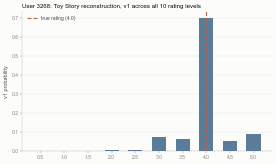

In [23]:
# cell 55
v1_ts_row = v1[ts_movie_col]
print("Toy Story v1 (reconstructed probability per rating level):")
for k, r in enumerate(RATING_LEVELS):
    marker = "  <- true rating" if k == ts_level_idx else ""
    print(f"  {r:.1f}: {v1_ts_row[k]:.4f}{marker}")

print()
for unit in (61, 53, 105):
    print(f"unit {unit}: h_prob_0={h_prob_0[unit]:.4f} (Step 1, from real v0)  ->  h1_prob={h1_prob[unit]:.4f} (Step 2, from reconstructed v1)")

import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

BAR_COLOR, REF_COLOR = "#5b7c99", "#b4654a"
fig, ax = plt.subplots(figsize=(7, 4.2), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
x = np.arange(K)
ax.bar(x, v1_ts_row, color=BAR_COLOR, width=0.6, zorder=3)
ax.axvline(ts_level_idx, color=REF_COLOR, linewidth=2, linestyle="--", zorder=4, label="true rating (4.0)")
ax.set_xticks(x)
ax.set_xticklabels([f"{r:.1f}" for r in RATING_LEVELS], fontsize=9)
ax.set_ylabel("v1 probability", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"User {DEMO_USER_ID}: Toy Story reconstruction, v1 across all 10 rating levels", color=INK_PRIMARY, fontsize=11, loc="left")
ax.legend(loc="upper left", frameon=False, fontsize=9, labelcolor=INK_SECONDARY)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(axis="y", color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_toystory_step2.png", dpi=150, facecolor=SURFACE)
plt.show()


*(cell 56)*

## Step 3 — Gradient estimate: $\Delta W_{(i,k),j} = \langle v_{i,k} h_j \rangle_{\text{data}} - \langle v_{i,k} h_j \rangle_{\text{recon}}$

This is the point of the whole CD-1 dance: contrasting statistics collected from the real data (Step 1) against statistics collected from the model's own reconstruction (Step 2) gives the direction to nudge each weight.

$$\langle v_{i,k} h_j \rangle_{\text{data}} := v^0_{i,k}\, h^0_j \qquad\qquad \langle v_{i,k} h_j \rangle_{\text{recon}} := v^1_{i,k}\, h^1_j$$

For the *data* term we use $h^0$, the Bernoulli sample from Step 1. For the *recon* term we use $h^1$ as a probability (no Bernoulli sample), matching the choice made in Step 2. Is-train: $v^0$ and $v^1$ are already zero at every unrated movie, so $\Delta W$ is automatically zero there too -- no separate user_movie_in_train step needed, but it's verified below rather than assumed.

This is a **single-user** estimate. In real training, $\Delta W$ gets averaged over an entire batch of users before being scaled by the learning rate and applied to $W$.


*(cell 57)*

##### 3.1 — $\Delta W$ = data statistics $-$ reconstruction statistics

pos  (data):  shape=(131290, 128)  nonzero=72384  sum=72384.0000
neg  (recon): shape=(131290, 128)  nonzero=890880  sum=88281.8766
delta_W = pos - neg: sum=-15897.8766


max |delta_W| at UNRATED movies: 0.000000  (should = 0.0 -- user_movie_in_train carries through automatically)
delta_W at RATED movies: min=-1.0000  max=1.0000  mean=-0.017845


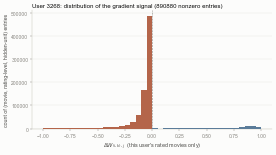

In [24]:
# cell 58
# Step 3: contrastive gradient estimate, this one user's contribution
pos = np.outer(v0, h0)          # <v h>_data,  from Step 1 (real v0, sampled h0)
neg = np.outer(v1, h1_prob)     # <v h>_recon, from Step 2 (reconstructed v1, probability h1)
delta_W = pos - neg

print(f"pos  (data):  shape={pos.shape}  nonzero={int((pos != 0).sum())}  sum={pos.sum():.4f}")
print(f"neg  (recon): shape={neg.shape}  nonzero={int((neg != 0).sum())}  sum={neg.sum():.4f}")
print(f"delta_W = pos - neg: sum={delta_W.sum():.4f}")

delta_W_reshaped = delta_W.reshape(n_movies, K, n_hidden)
unrated_max_abs = float(np.abs(delta_W_reshaped[unrated_cols]).max())
rated_vals = delta_W_reshaped[rated_cols].reshape(-1)
print(f"max |delta_W| at UNRATED movies: {unrated_max_abs:.6f}  (should = 0.0 -- user_movie_in_train carries through automatically)")
print(f"delta_W at RATED movies: min={rated_vals.min():.4f}  max={rated_vals.max():.4f}  mean={rated_vals.mean():.6f}")

import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
POS_COLOR, NEG_COLOR = "#5b7c99", "#b4654a"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

nonzero_vals = rated_vals[rated_vals != 0]
fig, ax = plt.subplots(figsize=(7, 4), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
counts, bins, patches = ax.hist(nonzero_vals, bins=40, color=POS_COLOR, zorder=3)
for patch, edge in zip(patches, bins[:-1]):
    if edge < 0:
        patch.set_facecolor(NEG_COLOR)
ax.axvline(0, color=INK_MUTED, linewidth=1, linestyle="--", zorder=2)
ax.set_xlabel(r"$\Delta W_{(i,k),j}$  (this user's rated movies only)", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel("count of (movie, rating-level, hidden-unit) entries", color=INK_SECONDARY, fontsize=9.5)
ax.set_title(f"User {DEMO_USER_ID}: distribution of the gradient signal ({len(nonzero_vals)} nonzero entries)", color=INK_PRIMARY, fontsize=11, loc="left")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(axis="y", color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_step3_gradient_hist.png", dpi=150, facecolor=SURFACE)
plt.show()


*(cell 59)*

### Step 3 — Gradient: delta_W = <v h>_data - <v h>_recon (cells 59-61)

$$\Delta W_{(i,k),j} = v^0_{i,k}\, h^0_j \;-\; v^1_{i,k}\, h^1_j$$

For Toy Story=4.0, comparing the data-phase product against the reconstruction-phase product, for the same 2 units.


*(cell 60)*

##### Step 3 data: the actual data-vs-recon subtraction for Toy Story=4.0

unit 61:
  data term  (v0 * h0)   = 1.0 * 1.0 = 1.0000
  recon term (v1 * h1)   = 0.6990 * 0.9999 = 0.6989
  delta_W = data - recon = +0.3011

unit 53:
  data term  (v0 * h0)   = 1.0 * 1.0 = 1.0000
  recon term (v1 * h1)   = 0.6990 * 0.9998 = 0.6989
  delta_W = data - recon = +0.3011

unit 105:
  data term  (v0 * h0)   = 1.0 * 1.0 = 1.0000
  recon term (v1 * h1)   = 0.6990 * 0.9988 = 0.6981
  delta_W = data - recon = +0.3019



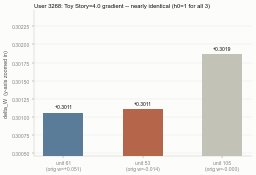

In [25]:
# cell 61
for unit in (61, 53, 105):
    data_term = v0.reshape(n_movies, K)[ts_movie_col, ts_level_idx] * h0[unit]
    recon_term = v1[ts_movie_col, ts_level_idx] * h1_prob[unit]
    dw = delta_W.reshape(n_movies, K, n_hidden)[ts_movie_col, ts_level_idx, unit]
    print(f"unit {unit}:")
    print(f"  data term  (v0 * h0)   = {v0.reshape(n_movies,K)[ts_movie_col,ts_level_idx]:.1f} * {h0[unit]:.1f} = {data_term:.4f}")
    print(f"  recon term (v1 * h1)   = {v1[ts_movie_col,ts_level_idx]:.4f} * {h1_prob[unit]:.4f} = {recon_term:.4f}")
    print(f"  delta_W = data - recon = {dw:+.4f}")
    print()

import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

units_ts = [61, 53, 105]
dws = [delta_W.reshape(n_movies, K, n_hidden)[ts_movie_col, ts_level_idx, u] for u in units_ts]
orig_w = [W_plus.reshape(n_movies, K, n_hidden)[ts_movie_col, ts_level_idx, u] for u in units_ts]
colors3 = ["#5b7c99" if w > 0.005 else ("#b4654a" if w < -0.005 else "#c3c2b7") for w in orig_w]

x = np.arange(len(units_ts))
y_lo, y_hi = min(dws) - 0.0006, max(dws) + 0.0006

fig, ax = plt.subplots(figsize=(6.5, 4.5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
bars = ax.bar(x, dws, color=colors3, width=0.5, zorder=3)
for b, v in zip(bars, dws):
    ax.text(b.get_x() + b.get_width() / 2, v + (y_hi - y_lo) * 0.03, f"{v:+.4f}", ha="center", fontsize=9, color=INK_PRIMARY)
ax.set_ylim(y_lo, y_hi)
ax.set_xticks(x)
ax.set_xticklabels([f"unit {u}\n(orig w={w:+.3f})" for u, w in zip(units_ts, orig_w)], fontsize=8.5)
ax.set_ylabel("delta_W  (y-axis zoomed in)", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"User {DEMO_USER_ID}: Toy Story=4.0 gradient -- nearly identical (h0=1 for all 3)", color=INK_PRIMARY, fontsize=10.5, loc="left")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(axis="y", color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_toystory_step3.png", dpi=150, facecolor=SURFACE)
plt.show()


*(cell 62)*

## Step 4 — Weight update: $W \leftarrow W + \eta \Delta W$, biases the same way

$$W_{(i,k),j} \leftarrow W_{(i,k),j} + \eta\, \Delta W_{(i,k),j}$$

$$b_j \leftarrow b_j + \eta\, \Delta b_j, \qquad \Delta b_j := \langle h_j \rangle_{\text{data}} - \langle h_j \rangle_{\text{recon}} = h^0_j - h^1_j$$

$\eta = 0.01$ -- the same learning rate actually used in 13b's training (`LR` in `train_rbm`). There is no visible bias term to update, consistent with everything built so far: e+'s trained model does not have one.

In real training, $\Delta W$ and $\Delta b$ are averaged over a whole batch of 500 users (`BATCH_SIZE` in 13b) before this update is applied. Here we apply it as if this single user's gradient were the whole batch, purely to show the mechanics -- this is illustrative only and does not modify the actual saved `W_plus` / `bh_plus`.


*(cell 63)*

##### 4.1 — Applying the update (illustrative -- one user standing in for a batch)

In [26]:
# cell 64
# Step 4: apply the update, using the same LR actually used in 13b's real training
LR = 0.01

delta_b_h = h0 - h1_prob   # <h>_data - <h>_recon, per hidden unit -- Step 3's contrast, applied to the bias
W_updated = W_plus + LR * delta_W
bh_updated = bh_plus + LR * delta_b_h

w_shift = (W_updated - W_plus)[rated_cols].reshape(-1)
print(f"delta_b_h: min={delta_b_h.min():.4f}  max={delta_b_h.max():.4f}  mean={delta_b_h.mean():.4f}")
print(f"W shift (LR * delta_W), rated-movie entries only: min={w_shift.min():.4f}  max={w_shift.max():.4f}")
print(f"for comparison, W itself has std~0.01-0.02 (from prior inspection) -- "
      f"one user's update is a small nudge, not a big jump; training needs many batches x many epochs to add up")


delta_b_h: min=-0.9955  max=0.0594  mean=-0.1785
W shift (LR * delta_W), rated-movie entries only: min=-0.0097  max=0.0097
for comparison, W itself has std~0.01-0.02 (from prior inspection) -- one user's update is a small nudge, not a big jump; training needs many batches x many epochs to add up


*(cell 65)*

### Step 4 — Update: W <- W + eta * delta_W (cells 65-67)

$$W_{(i,k),j} \leftarrow W_{(i,k),j} + \eta\, \Delta W_{(i,k),j}, \qquad \eta = 0.01$$

Before vs. after, for Toy Story=4.0, the same 2 units.


*(cell 66)*

##### Step 4 data: W before vs. after, for Toy Story=4.0

unit 61: W before = +0.05105   W after = +0.05406   shift = +0.00301  (= LR * delta_W)
unit 53: W before = -0.01384   W after = -0.01083   shift = +0.00301  (= LR * delta_W)
unit 105: W before = -0.00037   W after = +0.00265   shift = +0.00302  (= LR * delta_W)


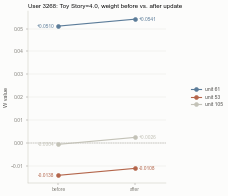

In [27]:
# cell 67
for unit in (61, 53, 105):
    w_before = W_plus.reshape(n_movies, K, n_hidden)[ts_movie_col, ts_level_idx, unit]
    w_after = W_updated.reshape(n_movies, K, n_hidden)[ts_movie_col, ts_level_idx, unit]
    print(f"unit {unit}: W before = {w_before:+.5f}   W after = {w_after:+.5f}   shift = {w_after - w_before:+.5f}  (= LR * delta_W)")

import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

units_ts = [61, 53, 105]
befores = [W_plus.reshape(n_movies, K, n_hidden)[ts_movie_col, ts_level_idx, u] for u in units_ts]
afters = [W_updated.reshape(n_movies, K, n_hidden)[ts_movie_col, ts_level_idx, u] for u in units_ts]
colors4 = ["#5b7c99", "#b4654a", "#c3c2b7"]

fig, ax = plt.subplots(figsize=(6, 5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
for i, (u, b, a, c) in enumerate(zip(units_ts, befores, afters, colors4)):
    ax.plot([0, 1], [b, a], color=c, linewidth=2, marker="o", markersize=7, zorder=3, label=f"unit {u}")
    ax.text(1.05, a, f"{a:+.4f}", va="center", fontsize=8.5, color=c)
    ax.text(-0.05, b, f"{b:+.4f}", va="center", ha="right", fontsize=8.5, color=c)
ax.axhline(0, color=INK_MUTED, linewidth=0.8, linestyle="--", zorder=1)
ax.set_xticks([0, 1])
ax.set_xticklabels(["before", "after"], fontsize=10)
ax.set_xlim(-0.4, 1.4)
ax.set_ylabel("W value", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"User {DEMO_USER_ID}: Toy Story=4.0, weight before vs. after update", color=INK_PRIMARY, fontsize=11, loc="left")
ax.legend(loc="center left", bbox_to_anchor=(1.15, 0.5), frameon=False, fontsize=9, labelcolor=INK_SECONDARY)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(axis="y", color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_toystory_step4.png", dpi=150, facecolor=SURFACE, bbox_inches="tight")
plt.show()


*(cell 68)*

## e− — same CD-1 mechanics, different input

Everything below reuses the exact same user_movie_in_train / sigmoid / Bernoulli mechanics already verified for e+ (Steps 1-4 above). The only thing that changes is **what the input represents**:

| | e+ | e− |
|---|---|---|
| data file | `channelB1_softmax.npy` | `channelDminus_5k.npy` |
| weights | `rbmB1_weights_5k.npy` / `rbmB1_bias_hidden_5k.npy` | `rbmDminus_weights_5k.npy` / `rbmDminus_bias_hidden_5k.npy` |
| K=10 bins mean | absolute rating level (0.5 ... 5.0) | deviation from this user's own train-mean rating, K=10 **symmetric** bins around 0 |
| trained in | notebook 13b | notebook 19 |

Both were trained with identical hyperparameters (`N_HIDDEN=128, LR=0.01, BATCH_SIZE=500, EPOCHS=50, INIT_SEED=42`) -- only the encoded meaning of $v$ differs.

In [28]:
# cell 69
W_minus = np.load(proc / "rbmDminus_weights_5k.npy")
bh_minus = np.load(proc / "rbmDminus_bias_hidden_5k.npy")
channelDminus = np.load(proc / "channelDminus_5k.npy", mmap_mode="r")
bin_edges = np.load(proc / "deviation_bin_edges_5k.npy")
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

print(f"e- : W {W_minus.shape}  bh {bh_minus.shape}  (frozen, trained in 19)")
print(f"channelDminus: {channelDminus.shape}")
print(f"deviation bin edges:   {np.round(bin_edges, 3)}")
print(f"deviation bin centers: {np.round(bin_centers, 3)}")


e- : W (131290, 128)  bh (128,)  (frozen, trained in 19)
channelDminus: (5000, 13129, 10)
deviation bin edges:   [-3.956 -3.165 -2.374 -1.582 -0.791  0.     0.791  1.582  2.374  3.165
  3.956]
deviation bin centers: [-3.56  -2.769 -1.978 -1.187 -0.396  0.396  1.187  1.978  2.769  3.56 ]


*(cell 70)*

##### Raw file peek: first few rows of each .npy file, no viewer needed

In [29]:
# cell 71
print("channelDminus_5k.npy -- shape", channelDminus.shape, channelDminus.dtype)
print("user 3268 (row", demo_row, "), first 5 movies:")
print(np.asarray(channelDminus[demo_row, :5, :]))

print("\nrbmDminus_weights_5k.npy (W_minus) -- shape", W_minus.shape, W_minus.dtype)
print("first 3 rows (movie x rating-level combos), first 8 hidden units:")
print(W_minus[:3, :8])

print("\nrbmDminus_bias_hidden_5k.npy (bh_minus) -- shape", bh_minus.shape)
print("first 10 values:")
print(bh_minus[:10])

print("\ndeviation_bin_edges_5k.npy -- shape", bin_edges.shape)
print(bin_edges)


channelDminus_5k.npy -- shape (5000, 13129, 10) float32
user 3268 (row 2499 ), first 5 movies:
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]

rbmDminus_weights_5k.npy (W_minus) -- shape (131290, 128) float64
first 3 rows (movie x rating-level combos), first 8 hidden units:
[[-0.03607283 -0.04847984 -0.03649549 -0.05239435 -0.07825035 -0.0467818
  -0.0528816  -0.03862243]
 [-0.04119752 -0.04366576 -0.0428781  -0.06778686 -0.04698849 -0.03432223
  -0.06198806 -0.04225579]
 [-0.02673234 -0.03344156 -0.03695823 -0.06278896 -0.05048174 -0.03154387
  -0.0422783  -0.03543327]]

rbmDminus_bias_hidden_5k.npy (bh_minus) -- shape (128,)
first 10 values:
[1.46162595 1.37884255 1.78191255 2.04656842 2.00951758 1.04899387
 1.89854916 1.1765327  1.39622305 1.78061565]

deviation_bin_edges_5k.npy -- shape (11,)
[-3.95610517 -3.16488414 -2.3736631  -1.58244207 -0.79122103  0.
  0.7912

*(cell 72)*

##### The input, in detail: same movies, but the bin now means "deviation from your own mean"

In [30]:
# cell 73
# same demo user, same sample movies as e+'s onehot-detail-code -- but decoded from channelDminus, not channelB1
v0_m = np.asarray(channelDminus[demo_row]).reshape(-1).astype(np.float64)
block_demo_m = np.asarray(channelDminus[demo_row, cols_demo, :])
user_mean = ratings_demo.mean()

print(f"User {DEMO_USER_ID}: train-mean rating = {user_mean:.4f}  (this is the reference point e- measures deviation from)\n")
print("Same 6 sample movies, e- input this time:")
for t, pidx in zip(sample_titles, picked_idx):
    row_oh_m = block_demo_m[pidx]
    k_hot = int(row_oh_m.argmax())
    real_rating = ratings_demo[pidx]
    print(f"  {t[:38]:38s} real_rating={real_rating:.1f}  deviation={real_rating - user_mean:+.2f}  "
          f"-> bin {k_hot} (center {bin_centers[k_hot]:+.2f})  onehot={row_oh_m.astype(int).tolist()}")


User 3268: train-mean rating = 3.6466  (this is the reference point e- measures deviation from)

Same 6 sample movies, e- input this time:
  Napoleon Dynamite (2004)               real_rating=0.5  deviation=-3.15  -> bin 1 (center -2.77)  onehot=[0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
  Zoolander (2001)                       real_rating=2.0  deviation=-1.65  -> bin 2 (center -1.98)  onehot=[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
  Casper (1995)                          real_rating=3.0  deviation=-0.65  -> bin 4 (center -0.40)  onehot=[0, 0, 0, 0, 1, 0, 0, 0, 0, 0]
  Jumanji (1995)                         real_rating=3.5  deviation=-0.15  -> bin 4 (center -0.40)  onehot=[0, 0, 0, 0, 1, 0, 0, 0, 0, 0]
  Toy Story (1995)                       real_rating=4.0  deviation=+0.35  -> bin 5 (center +0.40)  onehot=[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
  Léon: The Professional (a.k.a. The Pro real_rating=5.0  deviation=+1.35  -> bin 6 (center +1.19)  onehot=[0, 0, 0, 0, 0, 0, 1, 0, 0, 0]


*(cell 74)*

##### Same grid format as e+'s input table, columns are now deviation bins

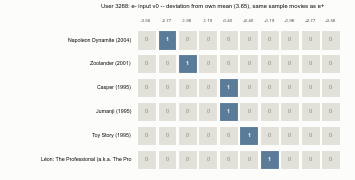

In [31]:
# cell 75
import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
SURFACE = "#fcfcfb"
ZERO_COLOR, ONE_COLOR = "#e1e0d9", "#5b7c99"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

n_sample = len(sample_titles)
fig, ax = plt.subplots(figsize=(9, 0.55 * n_sample + 1.3), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

for row_i, (t, pidx) in enumerate(zip(sample_titles, picked_idx)):
    row_oh_m = block_demo_m[pidx]
    for col_j in range(K):
        val = int(row_oh_m[col_j])
        color = ONE_COLOR if val == 1 else ZERO_COLOR
        ax.add_patch(plt.Rectangle((col_j, n_sample - 1 - row_i), 0.92, 0.8, facecolor=color, edgecolor=SURFACE, linewidth=2))
        txt_color = "white" if val == 1 else INK_MUTED
        ax.text(col_j + 0.46, n_sample - 1 - row_i + 0.4, str(val), ha="center", va="center", fontsize=10, color=txt_color, fontweight="bold" if val else "normal")
    ax.text(-0.3, n_sample - 1 - row_i + 0.4, t[:38], ha="right", va="center", fontsize=9.5, color=INK_PRIMARY)

for col_j in range(K):
    ax.text(col_j + 0.46, n_sample + 0.15, f"{bin_centers[col_j]:+.2f}", ha="center", fontsize=8, color=INK_SECONDARY)

ax.set_xlim(-6.5, K + 0.5)
ax.set_ylim(-0.3, n_sample + 0.6)
ax.axis("off")
ax.set_title(f"User {DEMO_USER_ID}: e- input v0 -- deviation from own mean ({user_mean:.2f}), same sample movies as e+", color=INK_PRIMARY, fontsize=10.5, loc="left", x=0.28)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_eminus_input_detail.png", dpi=150, facecolor=SURFACE)
plt.show()


*(cell 76)*

## e- Step 0 -- Where does W_ikj (e-) actually come from? A real, 2-epoch training trajectory (cells 76-80)

Same idea as e+'s Step 0: the weight values used below are the end result of 50 real epochs of CD-1 training on e-'s own data (notebook 19's Part 2), not a formula. This section re-runs 2 real epochs (same seed 42, same methodology) and tracks 3 representative weight values for Toy Story's deviation bin.

### Step 1 -- the formula

$$\Delta W^{(-)} = \eta \cdot \big(\langle v h\rangle_{\text{data}} - \langle v h\rangle_{\text{recon}}\big)$$

Same formula as e+, applied to e-'s own data and weights.

### Step 2 -- plug in the real data

Data source: `channelDminus_5k.npy` + `mask.npy` (same 5,000-user cohort), same hyperparameters (`N_HIDDEN=128, LR=0.01, BATCH_SIZE=500, INIT_SEED=42`) -- identical to notebook 19's actual e- training setup.

### Step 3 -- result

The table and chart below track Toy Story's deviation bin (bin 5, center +0.40) for 3 representative units. (Only 2 of the real 50 epochs are run here -- ending values will not yet match the final trained `W_minus`.)


*(cell 77)*

##### Re-running real training, 2 epochs, tracking only 3 weight values

In [32]:
# cell 78
import time

ts_level_idx_m = 5  # Toy Story's deviation bin for user 3268 (center +0.40) -- ts_movie_col reused from e+'s Step 0
units_ts_m = [36, 53, 21]  # e-'s own positive / negative / near-zero example units for this (movie, bin)

def expand_mask_batch_demo_m(m_movies, k):
    return np.repeat(m_movies, k, axis=1)

print("Loading the same real data used by notebook 19's actual e- training...")
channelDminus_full = np.load(proc / "channelDminus_5k.npy")
X1_demo_m = channelDminus_full.reshape(channelDminus_full.shape[0], -1)
del channelDminus_full
mask_full_m = np.load(proc / "mask.npy")
M2_demo_m = mask_full_m.astype(X1_demo_m.dtype, copy=False)
n_samples_demo_m, n_visible_demo_m = X1_demo_m.shape

def get_ts_weights_m(W_snapshot):
    row = W_snapshot.reshape(n_movies, K, n_hidden)[ts_movie_col, ts_level_idx_m, :]
    return {u: float(row[u]) for u in units_ts_m}

rng_demo_m = np.random.default_rng(42)  # same INIT_SEED as notebook 19
W_demo_m = rng_demo_m.normal(0.0, 0.01, size=(n_visible_demo_m, n_hidden)).astype(np.float64)
b_h_demo_m = np.zeros(n_hidden, dtype=np.float64)

trajectory_m = {"init (before any training)": get_ts_weights_m(W_demo_m)}
delta_log_m = {}
stat_log_m = {}
ts_flat_idx_m = ts_movie_col * K + ts_level_idx_m
print("init:", trajectory_m["init (before any training)"])

t0_all = time.perf_counter()
for epoch in range(2):
    t0 = time.perf_counter()
    epoch_delta = np.zeros_like(W_demo_m)
    data_stat_accum = {u: 0.0 for u in units_ts_m}
    recon_stat_accum = {u: 0.0 for u in units_ts_m}
    order = rng_demo_m.permutation(n_samples_demo_m)
    for start in range(0, n_samples_demo_m, 500):
        idx = order[start:start + 500]
        v_data = np.asarray(X1_demo_m[idx])
        m_batch = expand_mask_batch_demo_m(M2_demo_m[idx], K).astype(X1_demo_m.dtype)
        bs = v_data.shape[0]

        h_prob = sigmoid(v_data @ W_demo_m + b_h_demo_m)
        h_data = (rng_demo_m.random(h_prob.shape) < h_prob).astype(np.float64)

        v_recon_prob = sigmoid(h_data @ W_demo_m.T) * m_batch
        v_recon = (rng_demo_m.random(v_recon_prob.shape) < v_recon_prob).astype(np.float64) * m_batch

        h_recon_prob = sigmoid(v_recon @ W_demo_m + b_h_demo_m)
        h_recon = (rng_demo_m.random(h_recon_prob.shape) < h_recon_prob).astype(np.float64)

        pos = v_data.T @ h_data
        neg = v_recon.T @ h_recon
        epoch_delta += 0.01 * (pos - neg) / bs
        b_h_demo_m += 0.01 * (h_prob.mean(axis=0) - h_recon_prob.mean(axis=0))

        for u in units_ts_m:
            data_stat_accum[u] += pos[ts_flat_idx_m, u] / bs
            recon_stat_accum[u] += neg[ts_flat_idx_m, u] / bs

    delta_log_m[f"epoch {epoch + 1}"] = get_ts_weights_m(epoch_delta)
    stat_log_m[f"epoch {epoch + 1}"] = {
        u: {"data_stat": round(data_stat_accum[u], 5), "recon_stat": round(recon_stat_accum[u], 5),
            "data - recon": round(data_stat_accum[u] - recon_stat_accum[u], 5)}
        for u in units_ts_m
    }

    W_demo_m += epoch_delta
    dt = time.perf_counter() - t0
    ep = epoch + 1
    trajectory_m[f"after epoch {ep}"] = get_ts_weights_m(W_demo_m)
    print(f"epoch {ep} done in {dt:.1f}s")
    for u in units_ts_m:
        s = stat_log_m[f"epoch {ep}"][u]
        print(f"  unit {u}: data_stat={s['data_stat']:+.5f}  recon_stat={s['recon_stat']:+.5f}  "
              f"data-recon={s['data - recon']:+.5f}  x LR(0.01) = delta_W={delta_log_m[f'epoch {ep}'][u]:+.5f}")
    print(f"  W after applying it: {trajectory_m[f'after epoch {ep}']}")

print(f"\ntotal wall time: {time.perf_counter()-t0_all:.1f}s")
del X1_demo_m, M2_demo_m

print("\nStep 2, plugged in: the two raw pieces (<vh>_data, <vh>_recon) the formula subtracts, per epoch, per unit")
stat_rows_m = []
for ep_key, per_unit in stat_log_m.items():
    for u, vals in per_unit.items():
        stat_rows_m.append({"epoch": ep_key, "unit": u, **vals, "delta_W (x LR)": round(delta_log_m[ep_key][u], 5)})
stat_table_m = pd.DataFrame(stat_rows_m).set_index(["epoch", "unit"])
display(stat_table_m)

print("\nStep 3: W trajectory (init, then W += delta_W applied each epoch)")
traj_table_m = pd.DataFrame(trajectory_m).T
traj_table_m.index.name = "checkpoint"
display(traj_table_m)

print(f"\nfor comparison, actual W_minus after the real 50-epoch run: "
      f"{ {u: round(W_minus.reshape(n_movies,K,n_hidden)[ts_movie_col,ts_level_idx_m,u], 5) for u in units_ts_m} }")


Loading the same real data used by notebook 19's actual e- training...


init: {36: 0.023826022826840734, 53: -0.02251777290619047, 21: -0.0001756282647744591}


epoch 1 done in 27.7s
  unit 36: data_stat=+1.61200  recon_stat=+2.58400  data-recon=-0.97200  x LR(0.01) = delta_W=-0.00972
  unit 53: data_stat=+1.66800  recon_stat=+1.98800  data-recon=-0.32000  x LR(0.01) = delta_W=-0.00320
  unit 21: data_stat=+1.54800  recon_stat=+2.23600  data-recon=-0.68800  x LR(0.01) = delta_W=-0.00688
  W after applying it: {36: 0.014106022826840734, 53: -0.02571777290619047, 21: -0.007055628264774459}


epoch 2 done in 25.8s
  unit 36: data_stat=+0.08400  recon_stat=+0.00000  data-recon=+0.08400  x LR(0.01) = delta_W=+0.00084
  unit 53: data_stat=+0.40600  recon_stat=+0.00000  data-recon=+0.40600  x LR(0.01) = delta_W=+0.00406
  unit 21: data_stat=+0.15000  recon_stat=+0.00000  data-recon=+0.15000  x LR(0.01) = delta_W=+0.00150
  W after applying it: {36: 0.014946022826840735, 53: -0.02165777290619047, 21: -0.005555628264774459}

total wall time: 53.4s

Step 2, plugged in: the two raw pieces (<vh>_data, <vh>_recon) the formula subtracts, per epoch, per unit


data_stat  recon_stat  data - recon  delta_W (x LR)
epoch   unit                                                     
epoch 1 36        1.612       2.584        -0.972        -0.00972
        53        1.668       1.988        -0.320        -0.00320
        21        1.548       2.236        -0.688        -0.00688
epoch 2 36        0.084       0.000         0.084         0.00084
        53        0.406       0.000         0.406         0.00406
        21        0.150       0.000         0.150         0.00150


Step 3: W trajectory (init, then W += delta_W applied each epoch)


,36,53,21
checkpoint,,,
init (before any training),0.023826,-0.022518,-0.000176
after epoch 1,0.014106,-0.025718,-0.007056
after epoch 2,0.014946,-0.021658,-0.005556



for comparison, actual W_minus after the real 50-epoch run: {36: np.float64(0.06257), 53: np.float64(-0.07126), 21: np.float64(-0.0018)}


*(cell 79)*

##### Trajectory, as a chart

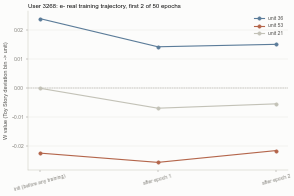

In [33]:
# cell 80
import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

palette_m = {36: "#5b7c99", 53: "#b4654a", 21: "#c3c2b7"}
x_labels_m = list(trajectory_m.keys())
x = np.arange(len(x_labels_m))

fig, ax = plt.subplots(figsize=(7.5, 5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
for u in units_ts_m:
    y = [trajectory_m[k][u] for k in x_labels_m]
    ax.plot(x, y, color=palette_m[u], linewidth=2, marker="o", markersize=6, zorder=3, label=f"unit {u}")
ax.axhline(0, color=INK_MUTED, linewidth=0.8, linestyle="--", zorder=1)
ax.set_xticks(x)
ax.set_xticklabels(x_labels_m, fontsize=9, rotation=15)
ax.set_ylabel("W value (Toy Story deviation bin -> unit)", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"User {DEMO_USER_ID}: e- real training trajectory, first 2 of 50 epochs", color=INK_PRIMARY, fontsize=11, loc="left")
ax.legend(loc="best", frameon=False, fontsize=9, labelcolor=INK_SECONDARY)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(axis="y", color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_eminus_weight_training.png", dpi=150, facecolor=SURFACE)
plt.show()


*(cell 81)*

### e− Step 1 — positive phase, mechanically identical to e+

$$I_j := b_j + \sum_{i,k} v^0_{i,k} W_{(i,k),j} \qquad h^0_j \sim \text{Bernoulli}(\sigma(I_j))$$

Same formula, same user_movie_in_train rule (only this user's rated, train-split movies contribute) -- just $v^0$, $W$, $b$ all swapped for e-'s own.


*(cell 82)*

##### Train-set membership (user_movie_in_train), verified (same check as e+)

In [34]:
# cell 83
rated_cols_m = np.where(np.asarray(mask[demo_row]) == 1)[0]
unrated_cols_m = np.where(np.asarray(mask[demo_row]) == 0)[0]
v0_m_reshaped = v0_m.reshape(n_movies, K)
print(f"v0_m: {int((v0_m != 0).sum())} nonzero entries total")
print(f"  at RATED positions ({len(rated_cols_m)} movies): {int(v0_m_reshaped[rated_cols_m].sum())} ones (should = {len(rated_cols_m)})")
print(f"  at UNRATED positions ({len(unrated_cols_m)} movies): {int(v0_m_reshaped[unrated_cols_m].sum())} ones (should = 0)")


v0_m: 696 nonzero entries total
  at RATED positions (696 movies): 696 ones (should = 696)
  at UNRATED positions (12433 movies): 0 ones (should = 0)


*(cell 84)*

##### Sigmoid: same S-curve, driven by e-'s own $I_j$

I_j_m:         min=0.9182  max=4.3964  mean=2.6219
h_prob_0_m = sigma(I_j_m):  min=0.7147  max=0.9878  mean=0.9212
first 10 values: [0.851 0.931 0.849 0.968 0.917 0.827 0.946 0.901 0.926 0.95 ]
(compare to e+'s h_prob_0: mean=0.8425)


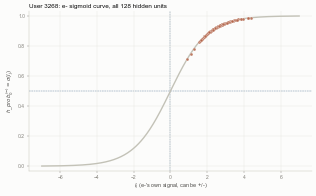

In [35]:
# cell 85
I_j_m = v0_m @ W_minus + bh_minus
h_prob_0_m = sigmoid(I_j_m)
print(f"I_j_m:         min={I_j_m.min():.4f}  max={I_j_m.max():.4f}  mean={I_j_m.mean():.4f}")
print(f"h_prob_0_m = sigma(I_j_m):  min={h_prob_0_m.min():.4f}  max={h_prob_0_m.max():.4f}  mean={h_prob_0_m.mean():.4f}")
print(f"first 10 values: {np.round(h_prob_0_m[:10], 3)}")
print(f"(compare to e+'s h_prob_0: mean={h_prob_0.mean():.4f})")

import matplotlib.pyplot as plt
import numpy as np

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
CURVE_COLOR, DOT_COLOR, REF_COLOR = "#c3c2b7", "#b4654a", "#5b7c99"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

x_curve = np.linspace(min(I_j_m.min(), -6) - 1, max(I_j_m.max(), 6) + 1, 400)
y_curve = sigmoid(x_curve)

fig, ax = plt.subplots(figsize=(8, 5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.plot(x_curve, y_curve, color=CURVE_COLOR, linewidth=2.5, zorder=2)
ax.scatter(I_j_m, h_prob_0_m, color=DOT_COLOR, s=28, zorder=3, alpha=0.85, edgecolors=SURFACE, linewidths=0.5)
ax.axhline(0.5, color=REF_COLOR, linewidth=0.8, linestyle="--", zorder=1)
ax.axvline(0, color=REF_COLOR, linewidth=0.8, linestyle="--", zorder=1)
ax.set_xlabel(r"$I_j$ (e-'s own signal, can be +/-)", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel(r"$h\_prob_0^{(-)} = \sigma(I_j)$", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"User {DEMO_USER_ID}: e- sigmoid curve, all {n_hidden} hidden units", color=INK_PRIMARY, fontsize=11.5, loc="left")
ax.set_ylim(-0.03, 1.03)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_eminus_step1_sigmoid.png", dpi=150, facecolor=SURFACE)
plt.show()


*(cell 86)*

##### Bernoulli sample: $h^{0,(-)}$

h0_m: 116 / 128 units sampled ON  (compare e+: 104 / 128)


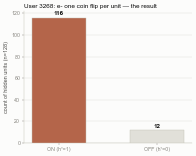

In [36]:
# cell 87
rng_cd1_m = np.random.default_rng(0)
h0_m = (rng_cd1_m.random(h_prob_0_m.shape) < h_prob_0_m).astype(np.float64)
print(f"h0_m: {int(h0_m.sum())} / {n_hidden} units sampled ON  (compare e+: {int(h0.sum())} / {n_hidden})")

import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
ON_COLOR, OFF_COLOR = "#b4654a", "#e1e0d9"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

n_on_m, n_off_m = int(h0_m.sum()), int(n_hidden - h0_m.sum())
fig, ax = plt.subplots(figsize=(5, 4), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
bars = ax.bar(["ON (h⁰=1)", "OFF (h⁰=0)"], [n_on_m, n_off_m], color=[ON_COLOR, OFF_COLOR], width=0.55, zorder=3, edgecolor=BASELINE, linewidth=0.8)
for b, v in zip(bars, [n_on_m, n_off_m]):
    ax.text(b.get_x() + b.get_width() / 2, v + max(n_on_m, n_off_m) * 0.02, f"{v}", ha="center", fontsize=11, color=INK_PRIMARY, fontweight="bold")
ax.set_ylabel(f"count of hidden units (n={n_hidden})", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"User {DEMO_USER_ID}: e- one coin flip per unit — the result", color=INK_PRIMARY, fontsize=11.5, loc="left")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9.5)
ax.grid(axis="y", color=GRID, linewidth=0.8, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_eminus_step1_bernoulli.png", dpi=150, facecolor=SURFACE)
plt.show()


*(cell 88)*

##### Combined: W (visible-side, e-) vs. h0_m (hidden-side, this user only)

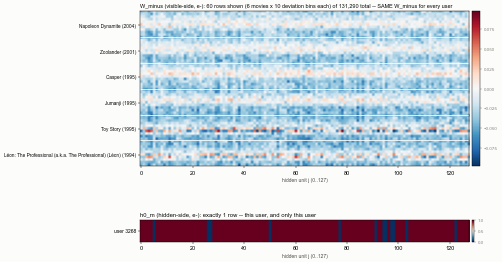

In [37]:
# cell 89
import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
SURFACE = "#fcfcfb"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

W_slice_m = W_minus.reshape(n_movies, K, n_hidden)[cols_demo[picked_idx]]  # (6 movies, 10 deviation bins, 128 hidden)
W_slice_m_flat = W_slice_m.reshape(-1, n_hidden)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7.5), facecolor=SURFACE, gridspec_kw={"height_ratios": [7, 1], "hspace": 0.6})

vmax = float(np.abs(W_slice_m_flat).max())
im1 = ax1.imshow(W_slice_m_flat, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
ax1.set_yticks([5 + 10 * i for i in range(len(sample_titles))])
ax1.set_yticklabels(sample_titles, fontsize=8.5, color=INK_PRIMARY)
for i in range(1, len(sample_titles)):
    ax1.axhline(i * 10 - 0.5, color=SURFACE, linewidth=1.5)
ax1.set_xlabel("hidden unit j (0..127)", fontsize=9, color=INK_SECONDARY)
ax1.set_title(f"W_minus (visible-side, e-): {W_slice_m_flat.shape[0]} rows shown (6 movies x 10 deviation bins each) of {n_movies*K:,} total -- SAME W_minus for every user", fontsize=10, color=INK_PRIMARY, loc="left")
cb1 = plt.colorbar(im1, ax=ax1, pad=0.01, fraction=0.025)
cb1.ax.tick_params(labelsize=8, colors=INK_MUTED)

im2 = ax2.imshow(h0_m.reshape(1, -1), aspect="auto", cmap="RdBu_r", vmin=0, vmax=1)
ax2.set_yticks([0])
ax2.set_yticklabels([f"user {DEMO_USER_ID}"], fontsize=9, color=INK_PRIMARY)
ax2.set_xlabel("hidden unit j (0..127)", fontsize=9, color=INK_SECONDARY)
ax2.set_title("h0_m (hidden-side, e-): exactly 1 row -- this user, and only this user", fontsize=10.5, color=INK_PRIMARY, loc="left")
cb2 = plt.colorbar(im2, ax=ax2, pad=0.01, fraction=0.025)
cb2.ax.tick_params(labelsize=8, colors=INK_MUTED)

plt.savefig(out_dir / f"user{DEMO_USER_ID}_eminus_movie_vs_user_side.png", dpi=150, facecolor=SURFACE, bbox_inches="tight")
plt.show()


*(cell 90)*

### Toy Story detail -- Step 1: v0_m -> h0_m

$$I_j = b_j + \sum_{(i,k)} v_{i,k}\, W^{(-)}_{(i,k),j} \qquad h\_prob_0^{(-)} = \sigma(I_j) \qquad h^{0,(-)} \sim \text{Bernoulli}(h\_prob_0^{(-)})$$

Same formula as e+, now on Toy Story's deviation bin (bin 5, center +0.40) and e-'s own 3 example units (36 positive, 53 negative, 21 near-zero).


*(cell 91)*

##### Setup: locate Toy Story's deviation bin, e-

Toy Story (1995): movie column=0, deviation bin=5 (center +0.40)
v0_m one-hot row for Toy Story: [0, 0, 0, 0, 0, 1, 0, 0, 0, 0]


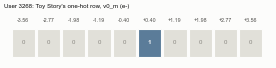

In [38]:
# cell 92
print(f"Toy Story (1995): movie column={ts_movie_col}, deviation bin={ts_level_idx_m} (center {bin_centers[ts_level_idx_m]:+.2f})")
print(f"v0_m one-hot row for Toy Story: {v0_m.reshape(n_movies, K)[ts_movie_col].astype(int).tolist()}")

import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
SURFACE = "#fcfcfb"
ZERO_COLOR, ONE_COLOR = "#e1e0d9", "#5b7c99"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

ts_row_m = v0_m.reshape(n_movies, K)[ts_movie_col].astype(int)

fig, ax = plt.subplots(figsize=(7, 1.8), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
for k in range(K):
    val = int(ts_row_m[k])
    color = ONE_COLOR if val == 1 else ZERO_COLOR
    ax.add_patch(plt.Rectangle((k, 0), 0.92, 0.8, facecolor=color, edgecolor=SURFACE, linewidth=2))
    txt_color = "white" if val == 1 else INK_MUTED
    ax.text(k + 0.46, 0.4, str(val), ha="center", va="center", fontsize=11, color=txt_color, fontweight="bold" if val else "normal")
for k in range(K):
    ax.text(k + 0.46, 1.0, f"{bin_centers[k]:+.2f}", ha="center", fontsize=9.5, color=INK_SECONDARY)

ax.set_xlim(-0.3, K + 0.3)
ax.set_ylim(-0.2, 1.3)
ax.axis("off")
ax.set_title(f"User {DEMO_USER_ID}: Toy Story's one-hot row, v0_m (e-)", color=INK_PRIMARY, fontsize=11, loc="left")
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_eminus_toystory_onehot.png", dpi=150, facecolor=SURFACE)
plt.show()


*(cell 93)*

##### Weighted sum: 696 movies -> I_j (Toy Story's term isolated)

,v_ik (Toy Story bin),W_ikj (weight),Toy Story's term (v*W),other 695 movies + bias,I_j (total)
unit,,,,,
36,1.0,0.06257,0.06257,1.82231,1.88487
53,1.0,-0.07126,-0.07126,2.32396,2.25270
21,1.0,-0.00180,-0.00180,2.05514,2.05334


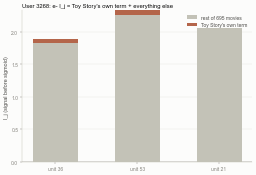

In [39]:
# cell 94
v_ts_m = v0_m.reshape(n_movies, K)[ts_movie_col, ts_level_idx_m]  # = 1 (Toy Story is in this deviation bin)

rows_m = []
for unit in units_ts_m:
    w_ts_m = W_minus.reshape(n_movies, K, n_hidden)[ts_movie_col, ts_level_idx_m, unit]
    ts_contribution_m = v_ts_m * w_ts_m
    other_695_m = I_j_m[unit] - ts_contribution_m
    rows_m.append({
        "unit": unit,
        "v_ik (Toy Story bin)": v_ts_m,
        "W_ikj (weight)": round(w_ts_m, 5),
        "Toy Story's term (v*W)": round(ts_contribution_m, 5),
        "other 695 movies + bias": round(other_695_m, 5),
        "I_j (total)": round(I_j_m[unit], 5),
    })
toystory_table_m = pd.DataFrame(rows_m).set_index("unit")
display(toystory_table_m)

import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

ts_terms_m = [v_ts_m * W_minus.reshape(n_movies, K, n_hidden)[ts_movie_col, ts_level_idx_m, u] for u in units_ts_m]
rest_terms_m = [I_j_m[u] - t for u, t in zip(units_ts_m, ts_terms_m)]

TS_COLOR, REST_COLOR = "#b4654a", "#c3c2b7"
fig, ax = plt.subplots(figsize=(6.5, 4.5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
x = np.arange(len(units_ts_m))
ax.bar(x, rest_terms_m, color=REST_COLOR, width=0.55, label="rest of 695 movies", zorder=3)
ax.bar(x, ts_terms_m, bottom=rest_terms_m, color=TS_COLOR, width=0.55, label="Toy Story's own term", zorder=3)
ax.axhline(0, color=INK_MUTED, linewidth=0.8, zorder=2)
ax.set_xticks(x)
ax.set_xticklabels([f"unit {u}" for u in units_ts_m], fontsize=9.5)
ax.set_ylabel("I_j (signal before sigmoid)", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"User {DEMO_USER_ID}: e- I_j = Toy Story's own term + everything else", color=INK_PRIMARY, fontsize=10.5, loc="left")
ax.legend(loc="upper right", frameon=False, fontsize=9, labelcolor=INK_SECONDARY)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(axis="y", color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_eminus_toystory_step1a.png", dpi=150, facecolor=SURFACE)
plt.show()


*(cell 95)*

##### Probability: I_j -> sigmoid -> h_prob_0

h_prob_0_m = sigma(I_j), for the same 3 units:
  unit 36: I_j=+1.8849  ->  h_prob_0_m=0.8682
  unit 53: I_j=+2.2527  ->  h_prob_0_m=0.9049
  unit 21: I_j=+2.0533  ->  h_prob_0_m=0.8863


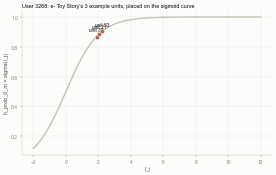

In [40]:
# cell 96
print("h_prob_0_m = sigma(I_j), for the same 3 units:")
for unit in units_ts_m:
    print(f"  unit {unit}: I_j={I_j_m[unit]:+.4f}  ->  h_prob_0_m={h_prob_0_m[unit]:.4f}")

import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
CURVE_COLOR, DOT_COLOR = "#c3c2b7", "#b4654a"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

x_curve = np.linspace(-2, 12, 300)
y_curve = sigmoid(x_curve)
fig, ax = plt.subplots(figsize=(7, 4.5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.plot(x_curve, y_curve, color=CURVE_COLOR, linewidth=2.5, zorder=2)
for unit in units_ts_m:
    ax.scatter([I_j_m[unit]], [h_prob_0_m[unit]], color=DOT_COLOR, s=60, zorder=3, edgecolors=SURFACE, linewidths=0.8)
    ax.annotate(f"unit {unit}", (I_j_m[unit], h_prob_0_m[unit]), textcoords="offset points", xytext=(0, 10), fontsize=8.5, ha="center", color=INK_PRIMARY)
ax.set_xlabel("I_j", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel("h_prob_0_m = sigma(I_j)", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"User {DEMO_USER_ID}: e- Toy Story's 3 example units, placed on the sigmoid curve", color=INK_PRIMARY, fontsize=10, loc="left")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_eminus_toystory_step1b.png", dpi=150, facecolor=SURFACE)
plt.show()


*(cell 97)*

##### Coin flip: h_prob_0 -> Bernoulli -> h0

h0_m ~ Bernoulli(h_prob_0_m), for the same 3 units:
  unit 36: h_prob_0_m=0.8682  ->  h0_m=1
  unit 53: h_prob_0_m=0.9049  ->  h0_m=1
  unit 21: h_prob_0_m=0.8863  ->  h0_m=1


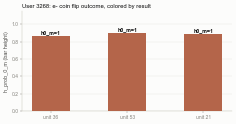

In [41]:
# cell 98
print("h0_m ~ Bernoulli(h_prob_0_m), for the same 3 units:")
for unit in units_ts_m:
    print(f"  unit {unit}: h_prob_0_m={h_prob_0_m[unit]:.4f}  ->  h0_m={int(h0_m[unit])}")

import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
SURFACE = "#fcfcfb"
ON_COLOR, OFF_COLOR = "#b4654a", "#e1e0d9"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

fig, ax = plt.subplots(figsize=(6, 3.2), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
for i, unit in enumerate(units_ts_m):
    color = ON_COLOR if h0_m[unit] == 1 else OFF_COLOR
    ax.bar([i], [h_prob_0_m[unit]], color=color, width=0.5, zorder=3)
    ax.text(i, h_prob_0_m[unit] + 0.02, f"h0_m={int(h0_m[unit])}", ha="center", fontsize=9.5, color=INK_PRIMARY, fontweight="bold")
ax.set_xticks(range(len(units_ts_m)))
ax.set_xticklabels([f"unit {u}" for u in units_ts_m], fontsize=9.5)
ax.set_ylabel("h_prob_0_m (bar height)", color=INK_SECONDARY, fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_title(f"User {DEMO_USER_ID}: e- coin flip outcome, colored by result", color=INK_PRIMARY, fontsize=10.5, loc="left")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(axis="y", color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_eminus_toystory_step1c.png", dpi=150, facecolor=SURFACE)
plt.show()


*(cell 99)*

### e− Step 2 — Reconstruction: h⁰ → v¹ → h¹ (same softmax + sigmoid rule as e+)

$$J_{i,k} := \sum_j W^{(-)}_{(i,k),j}\, h^{0,(-)}_j \qquad v^{1,(-)}_{i,k} = \frac{\exp(J_{i,k})}{\sum_{k'} \exp(J_{i,k'})}$$

Same softmax-over-K-bins rule (SMH 2007) as e+ -- the only difference is the K bins are deviation bins now, not absolute rating levels. $h^{1,(-)}$ is again probabilities only, no Bernoulli sample, same choice as e+.


*(cell 100)*

##### $h^{0,(-)} \to v^{1,(-)}$: softmax reconstruction, per movie

v1_m row sums at RATED movies:   min=1.0000  max=1.0000  (should = 1.0)
v1_m row sums at UNRATED movies: min=0.0000  max=0.0000  (should = 0.0)


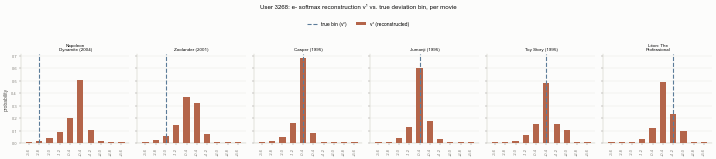

In [42]:
# cell 101
# e- Step 2, part A: h0_m -> softmax over each movie's K deviation bins -> v1_m
J_v_m = (h0_m @ W_minus.T).reshape(n_movies, K)
J_v_m_shift = J_v_m - J_v_m.max(axis=1, keepdims=True)
exp_J_m = np.exp(J_v_m_shift)
v1_m_full = exp_J_m / exp_J_m.sum(axis=1, keepdims=True)

v1_m = v1_m_full * mask_col[:, None]   # same mask_col as e+ (same user, same rated/unrated movies)

row_sums_m = v1_m.sum(axis=1)
print(f"v1_m row sums at RATED movies:   min={row_sums_m[rated_cols_m].min():.4f}  max={row_sums_m[rated_cols_m].max():.4f}  (should = 1.0)")
print(f"v1_m row sums at UNRATED movies: min={row_sums_m[unrated_cols_m].min():.4f}  max={row_sums_m[unrated_cols_m].max():.4f}  (should = 0.0)")

import textwrap

import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
TRUE_COLOR, RECON_COLOR = "#5b7c99", "#b4654a"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

def wrap_title(t, width=16, max_lines=2):
    t = t.split(" (a.k.a")[0]
    lines = textwrap.wrap(t, width)
    if len(lines) > max_lines:
        lines = lines[:max_lines]
        lines[-1] = lines[-1].rstrip() + "..."
    return "\n".join(lines)

n_sample = len(picked_idx)
fig, axes = plt.subplots(1, n_sample, figsize=(3.0 * n_sample, 3.4), facecolor=SURFACE, sharey=True)
if n_sample == 1:
    axes = [axes]

x = np.arange(K)
for ax, pidx, title in zip(axes, picked_idx, sample_titles):
    movie_col = cols_demo[pidx]
    true_row_m = block_demo_m[pidx]
    recon_row_m = v1_m[movie_col]
    ax.set_facecolor(SURFACE)
    ax.bar(x, recon_row_m, color=RECON_COLOR, width=0.6, zorder=3, label="v¹ (reconstructed)")
    true_k_m = int(true_row_m.argmax())
    ax.axvline(true_k_m, color=TRUE_COLOR, linewidth=2, linestyle="--", zorder=4, label="true bin (v⁰)")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{c:+.1f}" for c in bin_centers], rotation=90, fontsize=7)
    ax.set_title(wrap_title(title), fontsize=8, color=INK_PRIMARY)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(BASELINE)
    ax.tick_params(colors=INK_MUTED, labelsize=7.5)
    ax.grid(axis="y", color=GRID, linewidth=0.6, zorder=0)

axes[0].set_ylabel("probability", color=INK_SECONDARY, fontsize=9)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, fontsize=9, bbox_to_anchor=(0.5, 1.06))
fig.suptitle(f"User {DEMO_USER_ID}: e- softmax reconstruction v¹ vs. true deviation bin, per movie", fontsize=11, color=INK_PRIMARY, y=1.16)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_eminus_step2_softmax.png", dpi=150, facecolor=SURFACE, bbox_inches="tight")
plt.show()


*(cell 102)*

##### $v^{1,(-)}$ as a table, same format -- probabilities over deviation bins

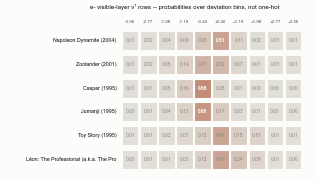

In [43]:
# cell 103
import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
SURFACE = "#fcfcfb"
ZERO_RGB, ONE_RGB = (0xe1, 0xe0, 0xd9), (0xb4, 0x65, 0x4a)
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

def blend(val):
    r = ZERO_RGB[0] + (ONE_RGB[0] - ZERO_RGB[0]) * val
    g = ZERO_RGB[1] + (ONE_RGB[1] - ZERO_RGB[1]) * val
    b = ZERO_RGB[2] + (ONE_RGB[2] - ZERO_RGB[2]) * val
    return (r / 255, g / 255, b / 255)

n_sample = len(sample_titles)
fig, ax = plt.subplots(figsize=(8, 0.55 * n_sample + 1.3), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

for row_i, (t, pidx) in enumerate(zip(sample_titles, picked_idx)):
    row_v1_m = v1_m[cols_demo[pidx]]
    for col_j in range(K):
        val = float(row_v1_m[col_j])
        color = blend(val)
        ax.add_patch(plt.Rectangle((col_j, n_sample - 1 - row_i), 0.92, 0.8, facecolor=color, edgecolor=SURFACE, linewidth=2))
        txt_color = "white" if val > 0.5 else INK_MUTED
        ax.text(col_j + 0.46, n_sample - 1 - row_i + 0.4, f"{val:.2f}", ha="center", va="center", fontsize=8.5, color=txt_color, fontweight="bold" if val > 0.5 else "normal")
    ax.text(-0.3, n_sample - 1 - row_i + 0.4, t[:38], ha="right", va="center", fontsize=9.5, color=INK_PRIMARY)

for col_j in range(K):
    ax.text(col_j + 0.46, n_sample + 0.15, f"{bin_centers[col_j]:+.2f}", ha="center", fontsize=8, color=INK_SECONDARY)

ax.set_xlim(-6.5, K + 0.5)
ax.set_ylim(-0.3, n_sample + 0.6)
ax.axis("off")
ax.set_title("e- visible-layer v¹ rows -- probabilities over deviation bins, not one-hot", color=INK_PRIMARY, fontsize=11, loc="left", x=0.28)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_eminus_v1_detail.png", dpi=150, facecolor=SURFACE)
plt.show()


*(cell 104)*

##### $v^{1,(-)} \to h^{1,(-)}$: sigmoid, probabilities only

I_j (from v1_m):          min=0.1517  max=3.5968  mean=2.2236
h1_prob_m = sigma(I_j_m): min=0.5379  max=0.9733  mean=0.8839
(compare to e-'s h_prob_0_m from Step 1, mean=0.9212)


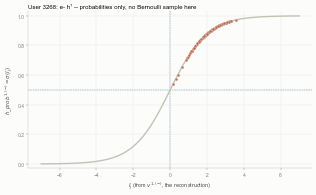


h1_prob_m - h_prob_0_m: min=-0.2106  max=0.0996  mean=-0.0372


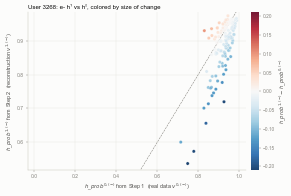

In [44]:
# cell 105
# e- Step 2, part B: v1_m -> sigmoid -> h1_m (probabilities only)
I_j_1_m = v1_m.reshape(-1) @ W_minus + bh_minus
h1_prob_m = sigmoid(I_j_1_m)
print(f"I_j (from v1_m):          min={I_j_1_m.min():.4f}  max={I_j_1_m.max():.4f}  mean={I_j_1_m.mean():.4f}")
print(f"h1_prob_m = sigma(I_j_m): min={h1_prob_m.min():.4f}  max={h1_prob_m.max():.4f}  mean={h1_prob_m.mean():.4f}")
print(f"(compare to e-'s h_prob_0_m from Step 1, mean={h_prob_0_m.mean():.4f})")

import matplotlib.pyplot as plt
import numpy as np

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
CURVE_COLOR, DOT_COLOR, REF_COLOR = "#c3c2b7", "#b4654a", "#5b7c99"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

x_curve = np.linspace(min(I_j_1_m.min(), -6) - 1, max(I_j_1_m.max(), 6) + 1, 400)
y_curve = sigmoid(x_curve)

fig, ax = plt.subplots(figsize=(8, 5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.plot(x_curve, y_curve, color=CURVE_COLOR, linewidth=2.5, zorder=2)
ax.scatter(I_j_1_m, h1_prob_m, color=DOT_COLOR, s=28, zorder=3, alpha=0.85, edgecolors=SURFACE, linewidths=0.5)
ax.axhline(0.5, color=REF_COLOR, linewidth=0.8, linestyle="--", zorder=1)
ax.axvline(0, color=REF_COLOR, linewidth=0.8, linestyle="--", zorder=1)
ax.set_xlabel(r"$I_j$ (from $v^{1,(-)}$, the reconstruction)", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel(r"$h\_prob^{1,(-)}=\sigma(I_j)$", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"User {DEMO_USER_ID}: e- h¹ -- probabilities only, no Bernoulli sample here", color=INK_PRIMARY, fontsize=11, loc="left")
ax.set_ylim(-0.03, 1.03)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_eminus_step2_sigmoid.png", dpi=150, facecolor=SURFACE)
plt.show()

# ---- h1_prob_m vs h_prob_0_m, continuous color, same style as e+'s comparison ----
diff_m = h1_prob_m - h_prob_0_m
print(f"\nh1_prob_m - h_prob_0_m: min={diff_m.min():.4f}  max={diff_m.max():.4f}  mean={diff_m.mean():.4f}")

y_lo_m = max(0.0, float(h1_prob_m.min()) - 0.02)
y_hi_m = min(1.01, float(h1_prob_m.max()) + 0.01)

fig, ax = plt.subplots(figsize=(7.5, 5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.plot([0, 1], [0, 1], color=INK_MUTED, linewidth=1, linestyle="--", zorder=2)
sc = ax.scatter(h_prob_0_m, h1_prob_m, c=diff_m, cmap="RdBu_r", vmin=-max(abs(diff_m.min()), abs(diff_m.max())), vmax=max(abs(diff_m.min()), abs(diff_m.max())),
                 s=34, zorder=3, alpha=0.9, edgecolors=SURFACE, linewidths=0.5)
cbar = plt.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label(r"$h\_prob^{1,(-)} - h\_prob^{0,(-)}$", color=INK_SECONDARY, fontsize=9.5)
cbar.ax.tick_params(colors=INK_MUTED, labelsize=8.5)
cbar.outline.set_visible(False)
ax.set_xlabel(r"$h\_prob^{0,(-)}$ from Step 1  (real data $v^{0,(-)}$)", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel(r"$h\_prob^{1,(-)}$ from Step 2  (reconstruction $v^{1,(-)}$)", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"User {DEMO_USER_ID}: e- h¹ vs h⁰, colored by size of change", color=INK_PRIMARY, fontsize=11, loc="left")
ax.set_xlim(-0.03, 1.03)
ax.set_ylim(y_lo_m, y_hi_m)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_eminus_step2_h0_vs_h1.png", dpi=150, facecolor=SURFACE)
plt.show()


*(cell 106)*

### e- Step 2 -- Reconstruction: h0_m -> v1_m -> h1_m, Toy Story detail (cells 106-108)

*(cell 107)*

##### Step 2 data: Toy Story's reconstructed distribution + h1_m for the same 3 units

Toy Story v1_m (reconstructed probability per deviation bin):
  -3.56: 0.0058
  -2.77: 0.0095
  -1.98: 0.0173
  -1.19: 0.0669
  -0.40: 0.1525
  +0.40: 0.4810  <- true bin
  +1.19: 0.1489
  +1.98: 0.1041
  +2.77: 0.0075
  +3.56: 0.0064

unit 36: h_prob_0_m=0.8682 (Step 1, from real v0_m)  ->  h1_prob_m=0.7946 (Step 2, from reconstructed v1_m)
unit 53: h_prob_0_m=0.9049 (Step 1, from real v0_m)  ->  h1_prob_m=0.8367 (Step 2, from reconstructed v1_m)
unit 21: h_prob_0_m=0.8863 (Step 1, from real v0_m)  ->  h1_prob_m=0.8649 (Step 2, from reconstructed v1_m)


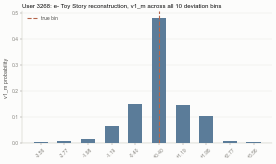

In [45]:
# cell 108
v1_ts_row_m = v1_m[ts_movie_col]
print("Toy Story v1_m (reconstructed probability per deviation bin):")
for k, c in enumerate(bin_centers):
    marker = "  <- true bin" if k == ts_level_idx_m else ""
    print(f"  {c:+.2f}: {v1_ts_row_m[k]:.4f}{marker}")

print()
for unit in units_ts_m:
    print(f"unit {unit}: h_prob_0_m={h_prob_0_m[unit]:.4f} (Step 1, from real v0_m)  ->  h1_prob_m={h1_prob_m[unit]:.4f} (Step 2, from reconstructed v1_m)")

import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

BAR_COLOR, REF_COLOR = "#5b7c99", "#b4654a"
fig, ax = plt.subplots(figsize=(7, 4.2), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
x = np.arange(K)
ax.bar(x, v1_ts_row_m, color=BAR_COLOR, width=0.6, zorder=3)
ax.axvline(ts_level_idx_m, color=REF_COLOR, linewidth=2, linestyle="--", zorder=4, label="true bin")
ax.set_xticks(x)
ax.set_xticklabels([f"{c:+.2f}" for c in bin_centers], fontsize=9, rotation=45)
ax.set_ylabel("v1_m probability", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"User {DEMO_USER_ID}: e- Toy Story reconstruction, v1_m across all 10 deviation bins", color=INK_PRIMARY, fontsize=11, loc="left")
ax.legend(loc="upper left", frameon=False, fontsize=9, labelcolor=INK_SECONDARY)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(axis="y", color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_eminus_toystory_step2.png", dpi=150, facecolor=SURFACE)
plt.show()


*(cell 109)*

### e− Step 3 — Gradient estimate: $\Delta W^{(-)} = \langle v h \rangle_{\text{data}} - \langle v h \rangle_{\text{recon}}$

Same contrast as e+, computed on e-'s own data/reconstruction pair.


*(cell 110)*

##### $\Delta W^{(-)}$ = data statistics $-$ reconstruction statistics

pos_m  (data):  sum=80736.0000
neg_m  (recon): sum=78745.5801
delta_W_m = pos_m - neg_m: sum=1990.4199


max |delta_W_m| at UNRATED movies: 0.000000  (should = 0.0)
delta_W_m at RATED movies: min=-0.9674  max=0.9989  mean=0.002234


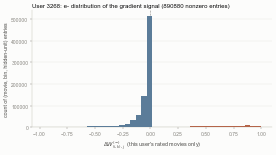

In [46]:
# cell 111
pos_m = np.outer(v0_m, h0_m)
neg_m = np.outer(v1_m, h1_prob_m)
delta_W_m = pos_m - neg_m

print(f"pos_m  (data):  sum={pos_m.sum():.4f}")
print(f"neg_m  (recon): sum={neg_m.sum():.4f}")
print(f"delta_W_m = pos_m - neg_m: sum={delta_W_m.sum():.4f}")

delta_W_m_reshaped = delta_W_m.reshape(n_movies, K, n_hidden)
unrated_max_abs_m = float(np.abs(delta_W_m_reshaped[unrated_cols_m]).max())
rated_vals_m = delta_W_m_reshaped[rated_cols_m].reshape(-1)
print(f"max |delta_W_m| at UNRATED movies: {unrated_max_abs_m:.6f}  (should = 0.0)")
print(f"delta_W_m at RATED movies: min={rated_vals_m.min():.4f}  max={rated_vals_m.max():.4f}  mean={rated_vals_m.mean():.6f}")

import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
POS_COLOR, NEG_COLOR = "#b4654a", "#5b7c99"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

nonzero_vals_m = rated_vals_m[rated_vals_m != 0]
fig, ax = plt.subplots(figsize=(7, 4), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
counts, bins_h, patches = ax.hist(nonzero_vals_m, bins=40, color=POS_COLOR, zorder=3)
for patch, edge in zip(patches, bins_h[:-1]):
    if edge < 0:
        patch.set_facecolor(NEG_COLOR)
ax.axvline(0, color=INK_MUTED, linewidth=1, linestyle="--", zorder=2)
ax.set_xlabel(r"$\Delta W^{(-)}_{(i,k),j}$  (this user's rated movies only)", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel("count of (movie, bin, hidden-unit) entries", color=INK_SECONDARY, fontsize=9.5)
ax.set_title(f"User {DEMO_USER_ID}: e- distribution of the gradient signal ({len(nonzero_vals_m)} nonzero entries)", color=INK_PRIMARY, fontsize=11, loc="left")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(axis="y", color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_eminus_step3_gradient_hist.png", dpi=150, facecolor=SURFACE)
plt.show()


*(cell 112)*

### e- Step 3 -- Gradient: delta_W_m = <v h>_data - <v h>_recon, Toy Story detail (cells 112-114)

*(cell 113)*

##### Step 3 data: the actual data-vs-recon subtraction for Toy Story's deviation bin

unit 36:
  data term  (v0_m * h0_m)   = 1.0 * 1.0 = 1.0000
  recon term (v1_m * h1_m)   = 0.4810 * 0.7946 = 0.3822
  delta_W_m = data - recon = +0.6178

unit 53:
  data term  (v0_m * h0_m)   = 1.0 * 1.0 = 1.0000
  recon term (v1_m * h1_m)   = 0.4810 * 0.8367 = 0.4025
  delta_W_m = data - recon = +0.5975

unit 21:
  data term  (v0_m * h0_m)   = 1.0 * 1.0 = 1.0000
  recon term (v1_m * h1_m)   = 0.4810 * 0.8649 = 0.4161
  delta_W_m = data - recon = +0.5839



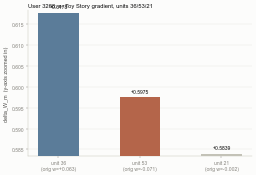

In [47]:
# cell 114
for unit in units_ts_m:
    data_term_m = v0_m.reshape(n_movies, K)[ts_movie_col, ts_level_idx_m] * h0_m[unit]
    recon_term_m = v1_m[ts_movie_col, ts_level_idx_m] * h1_prob_m[unit]
    dw_m = delta_W_m.reshape(n_movies, K, n_hidden)[ts_movie_col, ts_level_idx_m, unit]
    print(f"unit {unit}:")
    print(f"  data term  (v0_m * h0_m)   = {v0_m.reshape(n_movies,K)[ts_movie_col,ts_level_idx_m]:.1f} * {h0_m[unit]:.1f} = {data_term_m:.4f}")
    print(f"  recon term (v1_m * h1_m)   = {v1_m[ts_movie_col,ts_level_idx_m]:.4f} * {h1_prob_m[unit]:.4f} = {recon_term_m:.4f}")
    print(f"  delta_W_m = data - recon = {dw_m:+.4f}")
    print()

import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

dws_m = [delta_W_m.reshape(n_movies, K, n_hidden)[ts_movie_col, ts_level_idx_m, u] for u in units_ts_m]
orig_w_m = [W_minus.reshape(n_movies, K, n_hidden)[ts_movie_col, ts_level_idx_m, u] for u in units_ts_m]
colors3_m = ["#5b7c99" if w > 0.005 else ("#b4654a" if w < -0.005 else "#c3c2b7") for w in orig_w_m]

x = np.arange(len(units_ts_m))
y_lo_m, y_hi_m = min(dws_m) - 0.0006, max(dws_m) + 0.0006

fig, ax = plt.subplots(figsize=(6.5, 4.5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
bars = ax.bar(x, dws_m, color=colors3_m, width=0.5, zorder=3)
for b, v in zip(bars, dws_m):
    ax.text(b.get_x() + b.get_width() / 2, v + (y_hi_m - y_lo_m) * 0.03, f"{v:+.4f}", ha="center", fontsize=9, color=INK_PRIMARY)
ax.set_ylim(y_lo_m, y_hi_m)
ax.set_xticks(x)
ax.set_xticklabels([f"unit {u}\n(orig w={w:+.3f})" for u, w in zip(units_ts_m, orig_w_m)], fontsize=8.5)
ax.set_ylabel("delta_W_m  (y-axis zoomed in)", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"User {DEMO_USER_ID}: e- Toy Story gradient, units 36/53/21", color=INK_PRIMARY, fontsize=10.5, loc="left")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(axis="y", color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_eminus_toystory_step3.png", dpi=150, facecolor=SURFACE)
plt.show()


*(cell 115)*

### e− Step 4 — Weight update: $W^{(-)} \leftarrow W^{(-)} + \eta \Delta W^{(-)}$

Same $\eta=0.01$, same illustrative one-user-standing-in-for-a-batch caveat as e+.


*(cell 116)*

##### Applying the update (illustrative, e-)

In [48]:
# cell 117
delta_b_h_m = h0_m - h1_prob_m
W_minus_updated = W_minus + LR * delta_W_m
bh_minus_updated = bh_minus + LR * delta_b_h_m

w_shift_m = (W_minus_updated - W_minus)[rated_cols_m].reshape(-1)
print(f"delta_b_h_m: min={delta_b_h_m.min():.4f}  max={delta_b_h_m.max():.4f}  mean={delta_b_h_m.mean():.4f}")
print(f"W_m shift (LR * delta_W_m), rated-movie entries only: min={w_shift_m.min():.4f}  max={w_shift_m.max():.4f}")


delta_b_h_m: min=-0.9475  max=0.4621  mean=0.0223
W_m shift (LR * delta_W_m), rated-movie entries only: min=-0.0072  max=0.0098


*(cell 118)*

### e- Step 4 -- Update: W_m <- W_m + eta * delta_W_m, Toy Story detail (cells 118-120)

*(cell 119)*

##### Step 4 data: W_m before vs. after, for Toy Story's deviation bin

unit 36: W before = +0.06257   W after = +0.06874   shift = +0.00618  (= LR * delta_W_m)
unit 53: W before = -0.07126   W after = -0.06528   shift = +0.00598  (= LR * delta_W_m)
unit 21: W before = -0.00180   W after = +0.00404   shift = +0.00584  (= LR * delta_W_m)


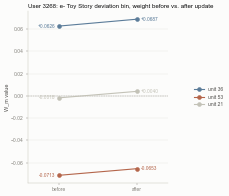

In [49]:
# cell 120
for unit in units_ts_m:
    w_before_m = W_minus.reshape(n_movies, K, n_hidden)[ts_movie_col, ts_level_idx_m, unit]
    w_after_m = W_minus_updated.reshape(n_movies, K, n_hidden)[ts_movie_col, ts_level_idx_m, unit]
    print(f"unit {unit}: W before = {w_before_m:+.5f}   W after = {w_after_m:+.5f}   shift = {w_after_m - w_before_m:+.5f}  (= LR * delta_W_m)")

import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

befores_m = [W_minus.reshape(n_movies, K, n_hidden)[ts_movie_col, ts_level_idx_m, u] for u in units_ts_m]
afters_m = [W_minus_updated.reshape(n_movies, K, n_hidden)[ts_movie_col, ts_level_idx_m, u] for u in units_ts_m]
colors4_m = ["#5b7c99", "#b4654a", "#c3c2b7"]

fig, ax = plt.subplots(figsize=(6, 5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
for i, (u, b, a, c) in enumerate(zip(units_ts_m, befores_m, afters_m, colors4_m)):
    ax.plot([0, 1], [b, a], color=c, linewidth=2, marker="o", markersize=7, zorder=3, label=f"unit {u}")
    ax.text(1.05, a, f"{a:+.4f}", va="center", fontsize=8.5, color=c)
    ax.text(-0.05, b, f"{b:+.4f}", va="center", ha="right", fontsize=8.5, color=c)
ax.axhline(0, color=INK_MUTED, linewidth=0.8, linestyle="--", zorder=1)
ax.set_xticks([0, 1])
ax.set_xticklabels(["before", "after"], fontsize=10)
ax.set_xlim(-0.4, 1.4)
ax.set_ylabel("W_m value", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"User {DEMO_USER_ID}: e- Toy Story deviation bin, weight before vs. after update", color=INK_PRIMARY, fontsize=11, loc="left")
ax.legend(loc="center left", bbox_to_anchor=(1.15, 0.5), frameon=False, fontsize=9, labelcolor=INK_SECONDARY)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(axis="y", color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_eminus_toystory_step4.png", dpi=150, facecolor=SURFACE, bbox_inches="tight")
plt.show()


*(cell 121)*

## e- -- user 3268, all 696 movies: what drives hidden units 36 / 53 / 21?

Single-movie (Toy Story) gave one data point per unit -- not enough to see a pattern. This section computes every one of this user's 696 rated movies' weight into the same 3 example units (36 positive, 53 negative, 21 near-zero, from Step 0), ranked, to look for structure.

*(cell 122)*

##### Weight per movie: v_ik * W_ikj, ranked, all 3 units

In [50]:
# cell 123
W_minus_r = W_minus.reshape(n_movies, K, n_hidden)
v0_m_r = v0_m.reshape(n_movies, K)

rows_all = []
for col in rated_cols_m:
    k = int(v0_m_r[col].argmax())
    mid = int(movie_vocab[col])
    title = movies_title_map.get(mid, "?")
    for unit in units_ts_m:
        rows_all.append({
            "unit": unit,
            "title": title,
            "deviation_bin_center": bin_centers[k],
            "weight": W_minus_r[col, k, unit],
        })

weight_df = pd.DataFrame(rows_all)

for unit in units_ts_m:
    sub = weight_df[weight_df["unit"] == unit].sort_values("weight", ascending=False)
    print(f"unit {unit}: top 5 pushing UP")
    display(sub.head(5)[["title", "deviation_bin_center", "weight"]])
    print(f"unit {unit}: top 5 pushing DOWN")
    display(sub.tail(5)[["title", "deviation_bin_center", "weight"]])
    print()


unit 36: top 5 pushing UP


,title,deviation_bin_center,weight
837,Catch Me If You Can (2002),0.395611,0.106262
0,Toy Story (1995),0.395611,0.062566
447,Good Will Hunting (1997),0.395611,0.060981
399,Donnie Brasco (1997),0.395611,0.057861
327,Goodfellas (1990),0.395611,0.054054


unit 36: top 5 pushing DOWN


,title,deviation_bin_center,weight
759,"Monsters, Inc. (2001)",1.186832,-0.061311
33,Seven (a.k.a. Se7en) (1995),1.186832,-0.061864
354,Stand by Me (1986),1.186832,-0.065588
297,Reservoir Dogs (1992),1.186832,-0.066794
291,Die Hard (1988),1.186832,-0.071650



unit 53: top 5 pushing UP


...

,title,deviation_bin_center,weight
361,Back to the Future (1985),0.395611,-0.054740
325,Star Wars: Episode VI - Return of the Jedi (1983),0.395611,-0.055877
310,Star Wars: Episode V - The Empire Strikes Back...,0.395611,-0.057461
142,Forrest Gump (1994),0.395611,-0.061822
1,Toy Story (1995),0.395611,-0.071258



unit 21: top 5 pushing UP


,title,deviation_bin_center,weight
839,Catch Me If You Can (2002),0.395611,0.088245
401,Donnie Brasco (1997),0.395611,0.059073
1190,Inside Man (2006),0.395611,0.052792
1541,Eastern Promises (2007),0.395611,0.052651
2012,Star Trek (2009),0.395611,0.043142


unit 21: top 5 pushing DOWN


,title,deviation_bin_center,weight
395,Jerry Maguire (1996),1.186832,-0.036271
629,"Green Mile, The (1999)",1.186832,-0.037500
608,Fight Club (1999),1.186832,-0.038479
332,Alien (1979),1.186832,-0.038808
41,"Usual Suspects, The (1995)",1.186832,-0.047346


*(cell 124)*

##### Chart: weight vs. deviation bin, all 696 movies

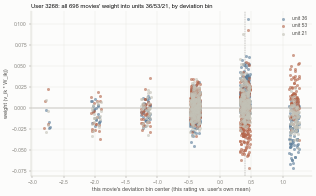

In [51]:
# cell 125
import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

palette = {36: "#5b7c99", 53: "#b4654a", 21: "#c3c2b7"}
rng_jitter = np.random.default_rng(7)

fig, ax = plt.subplots(figsize=(8, 5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
for unit in units_ts_m:
    sub = weight_df[weight_df["unit"] == unit]
    x = sub["deviation_bin_center"].values + rng_jitter.uniform(-0.08, 0.08, size=len(sub))
    ax.scatter(x, sub["weight"].values, s=18, alpha=0.6, color=palette[unit], label=f"unit {unit}", zorder=3)
ts_bin = bin_centers[ts_level_idx_m]
ax.axvline(ts_bin, color=INK_MUTED, linewidth=0.8, linestyle="--", zorder=1)
ax.axhline(0, color=INK_MUTED, linewidth=0.8, zorder=1)
ax.set_xlabel("this movie's deviation bin center (this rating vs. user's own mean)", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel("weight (v_ik * W_ikj)", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"User {DEMO_USER_ID}: all 696 movies' weight into units 36/53/21, by deviation bin", color=INK_PRIMARY, fontsize=10.5, loc="left")
ax.legend(loc="best", frameon=False, fontsize=9, labelcolor=INK_SECONDARY)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_eminus_allmovies_unit_contribution.png", dpi=150, facecolor=SURFACE)
plt.show()
